In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil
from pathlib import Path

import xarray as xr

from ewatercycle.models import Wflow
from ewatercycle.parameter_sets import available_parameter_sets
from ewatercycle.forcing import sources

project_dir = Path("/home/niels/BEP-Niels")

temp_dir = project_dir / "temp_runs"
results_dir = project_dir / "results"
figures_dir = project_dir / "Results-figures"

temp_dir.mkdir(exist_ok=True)
results_dir.mkdir(exist_ok=True)
figures_dir.mkdir(exist_ok=True)

print("Project map:", project_dir)
print("Temp runs:", temp_dir)
print("Results:", results_dir)
print("Figures:", figures_dir)

Project map: /home/niels/BEP-Niels
Temp runs: /home/niels/BEP-Niels/temp_runs
Results: /home/niels/BEP-Niels/results
Figures: /home/niels/BEP-Niels/Results-figures


In [3]:
grdc_file = project_dir / "Data Lobith" / "data grdc" / "6435060_Q_Day.Cmd.txt"

df = pd.read_csv(
    grdc_file,
    sep=";",
    comment="#",
    skipinitialspace=True,
    na_values=-999.000,
    encoding="latin1"
)

df.columns = df.columns.str.strip()

df = df.rename(columns={
    "YYYY-MM-DD": "date",
    "Value": "Q_m3s"
})

df["date"] = pd.to_datetime(df["date"])
df["Q_m3s"] = pd.to_numeric(df["Q_m3s"])

df = df.dropna(subset=["Q_m3s"])

print(df.head())
print("Start GRDC:", df["date"].min())
print("Einde GRDC:", df["date"].max())

        date  hh:mm   Q_m3s
0 1901-01-01  --:--  2035.0
1 1901-01-02  --:--  2270.0
2 1901-01-03  --:--  2445.0
3 1901-01-04  --:--  2325.0
4 1901-01-05  --:--  2175.0
Start GRDC: 1901-01-01 00:00:00
Einde GRDC: 2020-12-31 00:00:00


In [4]:
forcing_dir = temp_dir / "forcing_basisrun_1987_1995" / "work" / "diagnostic" / "script"
forcing_file = forcing_dir / "wflow_ERA5_Rhine_1986_1995.nc"

print("Forcing directory:", forcing_dir)
print("Directory bestaat:", forcing_dir.exists())
print("Forcing file:", forcing_file)
print("File bestaat:", forcing_file.exists())

Forcing directory: /home/niels/BEP-Niels/temp_runs/forcing_basisrun_1987_1995/work/diagnostic/script
Directory bestaat: True
Forcing file: /home/niels/BEP-Niels/temp_runs/forcing_basisrun_1987_1995/work/diagnostic/script/wflow_ERA5_Rhine_1986_1995.nc
File bestaat: True


In [5]:
ds = xr.open_dataset(forcing_file)

print(ds)
print("Start forcing:", ds["time"].values[0])
print("Einde forcing:", ds["time"].values[-1])
print("Variabelen:", list(ds.data_vars))

ds.close()

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 3652, lat: 169, lon: 187, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 29kB 1986-01-01T12:00:00 ... 1995-12-31T...
  * lat        (lat) float64 1kB 52.05 52.02 51.98 51.94 ... 45.97 45.93 45.89
  * lon        (lon) float64 1kB 5.227 5.264 5.3 5.337 ... 11.97 12.01 12.05
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    pr         (time, lat, lon) float32 462MB ...
    time_bnds  (time, bnds) datetime64[ns] 58kB ...
    lat_bnds   (lat, bnds) float64 3kB ...
    lon_bnds   (lon, bnds) float64 3kB ...
    tas        (time, lat, lon) float32 462MB ...
    pet        (time, lat, lon) float32 462MB ...
Attributes:
    Conventions:  CF-1.7
    software:     Created with ESMValTool v2.11.1
    caption:      Forcings for the wflow hydrological model.
Start forcing: 1986-01-01T12:00:00.000000000
Einde forcing: 1995-12-31T12:00:00.000000000
Variabelen: ['pr', 'time_bnds', 'lat_bnds', 'lon_bnds', '

In [6]:
shape_file = project_dir / "Rhine" / "Rhine.shp"

WflowForcing = sources["WflowForcing"]

forcing = WflowForcing(
    start_time="1986-01-01T00:00:00Z",
    end_time="1996-01-01T00:00:00Z",
    directory=str(forcing_dir),
    shape=str(shape_file),
    netcdfinput="wflow_ERA5_Rhine_1986_1995.nc",
    Precipitation="/pr",
    EvapoTranspiration="/pet",
    Temperature="/tas",
    Inflow=None,
)

print(forcing)

start_time='1986-01-01T00:00:00Z' end_time='1996-01-01T00:00:00Z' directory=PosixPath('/home/niels/BEP-Niels/temp_runs/forcing_basisrun_1987_1995/work/diagnostic/script') shape=PosixPath('/home/niels/BEP-Niels/Rhine/Rhine.shp') filenames={} netcdfinput='wflow_ERA5_Rhine_1986_1995.nc' Precipitation='/pr' EvapoTranspiration='/pet' Temperature='/tas' Inflow=None


In [7]:
parameter_sets = available_parameter_sets(target_model="wflow")
parameter_set = parameter_sets["wflow_rhine_sbm_nc"]

parameter_set.config = Path(parameter_set.directory) / "wflow_sbm_NC.ini"

print("Parameter set:", parameter_set.directory)
print("Config bestaat:", parameter_set.config.exists())

Parameter set: /data/shared/parameter-sets/wflow_rhine_sbm_nc
Config bestaat: True


In [8]:
lat_lobith_model = 51.849999998
lon_lobith_model = 6.0999999998

print("Lobith modelpunt:")
print("Latitude:", lat_lobith_model)
print("Longitude:", lon_lobith_model)

Lobith modelpunt:
Latitude: 51.849999998
Longitude: 6.0999999998


In [9]:
calibration_start = "1987-01-01"
calibration_end = "1995-12-31"

grdc_calibration = df[
    (df["date"] >= calibration_start) &
    (df["date"] <= calibration_end)
].copy()

grdc_calibration = grdc_calibration[["date", "Q_m3s"]]
grdc_calibration = grdc_calibration.rename(columns={"Q_m3s": "Q_grdc_m3s"})

print("Aantal GRDC dagen:", len(grdc_calibration))
print("Start:", grdc_calibration["date"].min())
print("Einde:", grdc_calibration["date"].max())

grdc_calibration.head()

Aantal GRDC dagen: 3287
Start: 1987-01-01 00:00:00
Einde: 1995-12-31 00:00:00


,date,Q_grdc_m3s
31411,1987-01-01,4865.0
31412,1987-01-02,5756.0
31413,1987-01-03,6160.0
31414,1987-01-04,6973.0
31415,1987-01-05,7579.0


In [10]:
def multiply_tbl_last_column(tbl_file, factor):
    tbl_file = Path(tbl_file)

    original_text = tbl_file.read_text()

    backup_file = tbl_file.with_suffix(tbl_file.suffix + ".backup")

    if not backup_file.exists():
        backup_file.write_text(original_text)

    new_lines = []

    for line in original_text.splitlines():
        stripped = line.strip()

        if stripped == "" or stripped.startswith("#"):
            new_lines.append(line)
            continue

        parts = line.split()

        try:
            old_value = float(parts[-1])
            new_value = old_value * factor
            parts[-1] = str(new_value)
            new_lines.append(" ".join(parts))

        except:
            new_lines.append(line)

    tbl_file.write_text("\n".join(new_lines) + "\n")

In [11]:
def apply_parameter_factors(cfg_dir, factors):
    cfg_dir = Path(cfg_dir)

    for tbl_name, factor in factors.items():
        found_files = list(cfg_dir.rglob(tbl_name))

        if len(found_files) == 0:
            print("Niet gevonden:", tbl_name)
            continue

        for tbl_file in found_files:
            print("Aanpassen:", tbl_file.relative_to(cfg_dir), "factor:", factor)
            multiply_tbl_last_column(tbl_file, factor)

In [12]:
def show_parameter_files(cfg_dir, tbl_name):
    cfg_dir = Path(cfg_dir)
    files = list(cfg_dir.rglob(tbl_name))

    print("Gevonden bestanden voor:", tbl_name)
    print("Aantal:", len(files))

    for file in files:
        print("\n---", file.relative_to(cfg_dir), "---")
        print(file.read_text())

In [13]:
test_run_dir = temp_dir / "run_test_parameter_change"

if test_run_dir.exists():
    shutil.rmtree(test_run_dir)

model_test = Wflow(
    parameter_set=parameter_set,
    forcing=forcing
)

cfg_file_test, cfg_dir_test = model_test.setup(
    cfg_dir=str(test_run_dir)
)

cfg_dir_test = Path(cfg_dir_test)

factors_test = {
    "FirstZoneCapacity.tbl": 1.5
}

print("VOOR aanpassing:")
show_parameter_files(cfg_dir_test, "FirstZoneCapacity.tbl")

apply_parameter_factors(cfg_dir_test, factors_test)

print("\nNA aanpassing:")
show_parameter_files(cfg_dir_test, "FirstZoneCapacity.tbl")

VOOR aanpassing:
Gevonden bestanden voor: FirstZoneCapacity.tbl
Aantal: 1

--- intbl/FirstZoneCapacity.tbl ---
1	1	1	400
2	1	1	7100
3	1	1	7100
4	1	1	7100
5	1	1	7100
6	1	1	7100
1	2	1	3200
2	2	1	10000
3	2	1	10000
4	2	1	10000
5	2	1	10000
6	2	1	10000
1	3	1	400
2	3	1	1000
3	3	1	1000
4	3	1	1000
5	3	1	1000
6	3	1	1000
1	4	1	800
2	4	1	14200
3	4	1	14200
4	4	1	14200
5	4	1	14200
6	4	1	14200
1	5	1	800
2	5	1	14200
3	5	1	14200
4	5	1	14200
5	5	1	14200
6	5	1	14200
1	6	1	800
2	6	1	14200
3	6	1	14200
4	6	1	14200
5	6	1	14200
6	6	1	14200
1	7	1	1200
2	7	1	6750
3	7	1	6750
4	7	1	6750
5	7	1	6750
6	7	1	6750
1	8	1	400
2	8	1	1750
3	8	1	1750
4	8	1	1750
5	8	1	1750
6	8	1	1750
1	9	1	800
2	9	1	14200
3	9	1	14200
4	9	1	14200
5	9	1	14200
6	9	1	14200
1	10	1	800
2	10	1	14200
3	10	1	14200
4	10	1	14200
5	10	1	14200
6	10	1	14200
1	11	1	12800
2	11	1	24000
3	11	1	24000
4	11	1	24000
5	11	1	24000
6	11	1	24000
1	12	1	400
2	12	1	1250
3	12	1	1250
4	12	1	1250
5	12	1	1250
6	12	1	1250
1	13	1	1600
2	13	1	3000
3	13	1	3000
4	13	1	3000
5	13

In [14]:
def get_tbl_last_column_values(tbl_file):
    values = []
    
    tbl_file = Path(tbl_file)
    
    for line in tbl_file.read_text().splitlines():
        stripped = line.strip()
        
        if stripped == "" or stripped.startswith("#"):
            continue
        
        parts = line.split()
        
        try:
            values.append(float(parts[-1]))
        except:
            pass
    
    return values

In [15]:
def print_parameter_summary(cfg_dir, factors):
    cfg_dir = Path(cfg_dir)
    
    for tbl_name in factors.keys():
        files = list(cfg_dir.rglob(tbl_name))
        
        print("\nParameter:", tbl_name)
        print("Aantal bestanden gevonden:", len(files))
        
        for file in files:
            values = get_tbl_last_column_values(file)
            
            if len(values) > 0:
                print(file.relative_to(cfg_dir))
                print("min:", min(values), "max:", max(values), "mean:", round(np.mean(values), 2))

In [16]:
def run_calibration_model(run_name, factors):
    cfg_dir_test = temp_dir / f"run_{run_name}"

    if cfg_dir_test.exists():
        print("Oude runmap verwijderen:")
        print(cfg_dir_test)
        shutil.rmtree(cfg_dir_test)

    model_test = Wflow(
        parameter_set=parameter_set,
        forcing=forcing
    )

    cfg_file_test, cfg_dir_test = model_test.setup(
        cfg_dir=str(cfg_dir_test)
    )

    cfg_dir_test = Path(cfg_dir_test)

    print("Runmap aangemaakt:")
    print(cfg_dir_test)

    if len(factors) > 0:
        print("\nParameters vóór aanpassing:")
        print_parameter_summary(cfg_dir_test, factors)

        apply_parameter_factors(cfg_dir_test, factors)

        print("\nParameters na aanpassing:")
        print_parameter_summary(cfg_dir_test, factors)
    else:
        print("\nGeen parameters aangepast: basisrun")

    model_test.initialize(cfg_file_test)

    Q_model = []
    time_model = []

    i = 0

    while model_test.time < model_test.end_time:
        model_test.update()

        q_lobith = model_test.get_value_at_coords(
            "RiverRunoff",
            lat=[float(lat_lobith_model)],
            lon=[float(lon_lobith_model)]
        )[0]

        Q_model.append(float(q_lobith))
        time_model.append(model_test.time_as_datetime)

        i += 1

        if i % 365 == 0:
            print("Stap:", i, "Tijd:", model_test.time_as_datetime, "Q:", round(float(q_lobith), 1))

    model_test.finalize()

    output = pd.DataFrame({
        "date": pd.to_datetime(time_model, utc=True),
        "Q_model_m3s": Q_model
    })

    output["date"] = output["date"].dt.tz_convert(None).dt.floor("D")

    output = output[
        (output["date"] >= calibration_start) &
        (output["date"] <= calibration_end)
    ].copy()

    output_file = results_dir / f"{run_name}_lobith_daily.csv"
    output.to_csv(output_file, index=False)

    print("\nRun klaar:", run_name)
    print("Aantal dagen:", len(output))
    print("Opgeslagen als:", output_file)

    return output

In [17]:
basis_file = results_dir / "basisrun_1987_1995_lobith_daily.csv"

if basis_file.exists():
    print("Bestaande basisrun gevonden:")
    print(basis_file)
    
    model_basis = pd.read_csv(basis_file)
    model_basis["date"] = pd.to_datetime(model_basis["date"])
    
else:
    print("Geen bestaande basisrun gevonden. Basisrun wordt nu gedraaid.")
    
    model_basis = run_calibration_model(
        run_name="basisrun_1987_1995",
        factors={}
    )

if "Q_model_m3s" in model_basis.columns:
    model_basis = model_basis.rename(columns={"Q_model_m3s": "Q_basis_m3s"})

model_basis.head()

Bestaande basisrun gevonden:
/home/niels/BEP-Niels/results/basisrun_1987_1995_lobith_daily.csv


,date,Q_basis_m3s
0,1987-01-01,13869.678711
1,1987-01-02,15741.568359
2,1987-01-03,16061.675781
3,1987-01-04,15124.300781
4,1987-01-05,13978.630859


In [18]:
comparison = pd.merge(
    grdc_calibration,
    model_basis,
    on="date",
    how="inner"
)

print("Aantal vergelijkingsdagen:", len(comparison))
print("Start:", comparison["date"].min())
print("Einde:", comparison["date"].max())

comparison.head()

Aantal vergelijkingsdagen: 1826
Start: 1987-01-01 00:00:00
Einde: 1991-12-31 00:00:00


,date,Q_grdc_m3s,Q_basis_m3s
0,1987-01-01,4865.0,13869.678711
1,1987-01-02,5756.0,15741.568359
2,1987-01-03,6160.0,16061.675781
3,1987-01-04,6973.0,15124.300781
4,1987-01-05,7579.0,13978.630859


In [19]:
def calculate_scores(data, obs_col, sim_col):
    d = data[[obs_col, sim_col]].dropna().copy()
    
    obs = d[obs_col].astype(float)
    sim = d[sim_col].astype(float)
    
    bias = (sim - obs).mean()
    rmse = np.sqrt(((sim - obs) ** 2).mean())
    
    eps = 1.0
    log_obs = np.log(obs.clip(lower=eps))
    log_sim = np.log(sim.clip(lower=eps))
    
    log_nse = 1 - ((log_sim - log_obs) ** 2).sum() / ((log_obs - log_obs.mean()) ** 2).sum()
    
    return {
        "bias_m3s": bias,
        "rmse_m3s": rmse,
        "log_nse": log_nse,
        "n_days": len(d)
    }

In [20]:
def make_score_table(data, model_columns, obs_col="Q_grdc_m3s"):
    rows = []
    
    for run_name, sim_col in model_columns.items():
        scores = calculate_scores(data, obs_col, sim_col)
        scores["run"] = run_name
        rows.append(scores)
    
    table = pd.DataFrame(rows)
    table = table[["run", "bias_m3s", "rmse_m3s", "log_nse", "n_days"]]
    
    table["bias_m3s"] = table["bias_m3s"].round(1)
    table["rmse_m3s"] = table["rmse_m3s"].round(1)
    table["log_nse"] = table["log_nse"].round(3)
    
    return table

In [21]:
model_columns = {
    "basisrun": "Q_basis_m3s"
}

score_all = make_score_table(
    comparison,
    model_columns
)

score_low = make_score_table(
    comparison[comparison["Q_grdc_m3s"] < 1600],
    model_columns
)

score_all

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,basisrun,582.0,1876.4,-1.042,1826


In [22]:
score_low

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,basisrun,-147.0,740.8,-21.205,669


In [23]:
# Modelperiode beperken tot 1986-1991
# 1986 = warm-up
# 1987-1991 = vergelijking

model_start = "1986-01-01T00:00:00Z"
model_end = "1992-01-01T00:00:00Z"

calibration_start = "1987-01-01"
calibration_end = "1991-12-31"

WflowForcing = sources["WflowForcing"]

forcing = WflowForcing(
    start_time=model_start,
    end_time=model_end,
    directory=str(forcing_dir),
    shape=str(shape_file),
    netcdfinput="wflow_ERA5_Rhine_1986_1995.nc",
    Precipitation="/pr",
    EvapoTranspiration="/pet",
    Temperature="/tas",
    Inflow=None,
)

print(forcing)
print("Model start:", model_start)
print("Model end:", model_end)
print("Vergelijking:", calibration_start, "t/m", calibration_end)

start_time='1986-01-01T00:00:00Z' end_time='1992-01-01T00:00:00Z' directory=PosixPath('/home/niels/BEP-Niels/temp_runs/forcing_basisrun_1987_1995/work/diagnostic/script') shape=PosixPath('/home/niels/BEP-Niels/Rhine/Rhine.shp') filenames={} netcdfinput='wflow_ERA5_Rhine_1986_1995.nc' Precipitation='/pr' EvapoTranspiration='/pet' Temperature='/tas' Inflow=None
Model start: 1986-01-01T00:00:00Z
Model end: 1992-01-01T00:00:00Z
Vergelijking: 1987-01-01 t/m 1991-12-31


In [24]:
grdc_calibration = df[
    (df["date"] >= calibration_start) &
    (df["date"] <= calibration_end)
].copy()

grdc_calibration = grdc_calibration[["date", "Q_m3s"]]
grdc_calibration = grdc_calibration.rename(columns={"Q_m3s": "Q_grdc_m3s"})

print("Aantal GRDC dagen:", len(grdc_calibration))
print("Start:", grdc_calibration["date"].min())
print("Einde:", grdc_calibration["date"].max())

grdc_calibration.head()

Aantal GRDC dagen: 1826
Start: 1987-01-01 00:00:00
Einde: 1991-12-31 00:00:00


,date,Q_grdc_m3s
31411,1987-01-01,4865.0
31412,1987-01-02,5756.0
31413,1987-01-03,6160.0
31414,1987-01-04,6973.0
31415,1987-01-05,7579.0


In [26]:
basis_file = results_dir / "basisrun_1987_1995_lobith_daily.csv"

if basis_file.exists():
    print("Bestaande basisrun gevonden:")
    print(basis_file)
    
    model_basis = pd.read_csv(basis_file)
    model_basis["date"] = pd.to_datetime(model_basis["date"])
    
else:
    print("Geen basisrun-bestand met deze naam gevonden.")
    print("We gebruiken de bestaande model_basis als die al in het notebook staat.")

Bestaande basisrun gevonden:
/home/niels/BEP-Niels/results/basisrun_1987_1995_lobith_daily.csv


In [27]:
if "Q_model_m3s" in model_basis.columns:
    model_basis = model_basis.rename(columns={"Q_model_m3s": "Q_basis_m3s"})

model_basis = model_basis[
    (model_basis["date"] >= calibration_start) &
    (model_basis["date"] <= calibration_end)
].copy()

print("Start basis:", model_basis["date"].min())
print("Einde basis:", model_basis["date"].max())
print("Aantal dagen basis:", len(model_basis))

model_basis.head()

Start basis: 1987-01-01 00:00:00
Einde basis: 1991-12-31 00:00:00
Aantal dagen basis: 1826


,date,Q_basis_m3s
0,1987-01-01,13869.678711
1,1987-01-02,15741.568359
2,1987-01-03,16061.675781
3,1987-01-04,15124.300781
4,1987-01-05,13978.630859


In [28]:
comparison = pd.merge(
    grdc_calibration,
    model_basis,
    on="date",
    how="inner"
)

print("Aantal vergelijkingsdagen:", len(comparison))
print("Start:", comparison["date"].min())
print("Einde:", comparison["date"].max())

comparison.head()

Aantal vergelijkingsdagen: 1826
Start: 1987-01-01 00:00:00
Einde: 1991-12-31 00:00:00


,date,Q_grdc_m3s,Q_basis_m3s
0,1987-01-01,4865.0,13869.678711
1,1987-01-02,5756.0,15741.568359
2,1987-01-03,6160.0,16061.675781
3,1987-01-04,6973.0,15124.300781
4,1987-01-05,7579.0,13978.630859


In [29]:
factors = {
    "FirstZoneCapacity.tbl": 1.5
}

model_lowflow_1 = run_calibration_model(
    run_name="lowflow_FirstZoneCapacity_x15_1987_1991",
    factors=factors
)

Runmap aangemaakt:
/home/niels/BEP-Niels/temp_runs/run_lowflow_FirstZoneCapacity_x15_1987_1991

Parameters vóór aanpassing:

Parameter: FirstZoneCapacity.tbl
Aantal bestanden gevonden: 1
intbl/FirstZoneCapacity.tbl
min: 400.0 max: 24000.0 mean: 7830.95
Aanpassen: intbl/FirstZoneCapacity.tbl factor: 1.5

Parameters na aanpassing:

Parameter: FirstZoneCapacity.tbl
Aantal bestanden gevonden: 1
intbl/FirstZoneCapacity.tbl
min: 600.0 max: 36000.0 mean: 11746.43
Stap: 365 Tijd: 1986-12-31 00:00:00 Q: 11876.8
Stap: 730 Tijd: 1987-12-31 00:00:00 Q: 2224.0
Stap: 1095 Tijd: 1988-12-30 00:00:00 Q: 3958.7
Stap: 1460 Tijd: 1989-12-30 00:00:00 Q: 4676.8
Stap: 1825 Tijd: 1990-12-30 00:00:00 Q: 6410.8
Stap: 2190 Tijd: 1991-12-30 00:00:00 Q: 7189.5

Run klaar: lowflow_FirstZoneCapacity_x15_1987_1991
Aantal dagen: 1826
Opgeslagen als: /home/niels/BEP-Niels/results/lowflow_FirstZoneCapacity_x15_1987_1991_lobith_daily.csv


In [30]:
model_lowflow_1 = model_lowflow_1.rename(
    columns={"Q_model_m3s": "Q_lowflow_1_m3s"}
)

comparison_lowflow_1 = pd.merge(
    comparison,
    model_lowflow_1[["date", "Q_lowflow_1_m3s"]],
    on="date",
    how="inner"
)

comparison_lowflow_1.head()

,date,Q_grdc_m3s,Q_basis_m3s,Q_lowflow_1_m3s
0,1987-01-01,4865.0,13869.678711,13869.678711
1,1987-01-02,5756.0,15741.568359,15741.568359
2,1987-01-03,6160.0,16061.675781,16061.675781
3,1987-01-04,6973.0,15124.300781,15124.300781
4,1987-01-05,7579.0,13978.630859,13978.630859


In [31]:
model_columns = {
    "basisrun": "Q_basis_m3s",
    "lowflow_1": "Q_lowflow_1_m3s"
}

score_all = make_score_table(
    comparison_lowflow_1,
    model_columns
)

score_low = make_score_table(
    comparison_lowflow_1[
        comparison_lowflow_1["Q_grdc_m3s"] < 1600
    ],
    model_columns
)

score_all

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,basisrun,582.0,1876.4,-1.042,1826
1,lowflow_1,582.0,1876.4,-1.042,1826


In [32]:
score_low

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,basisrun,-147.0,740.8,-21.205,669
1,lowflow_1,-147.0,740.8,-21.205,669


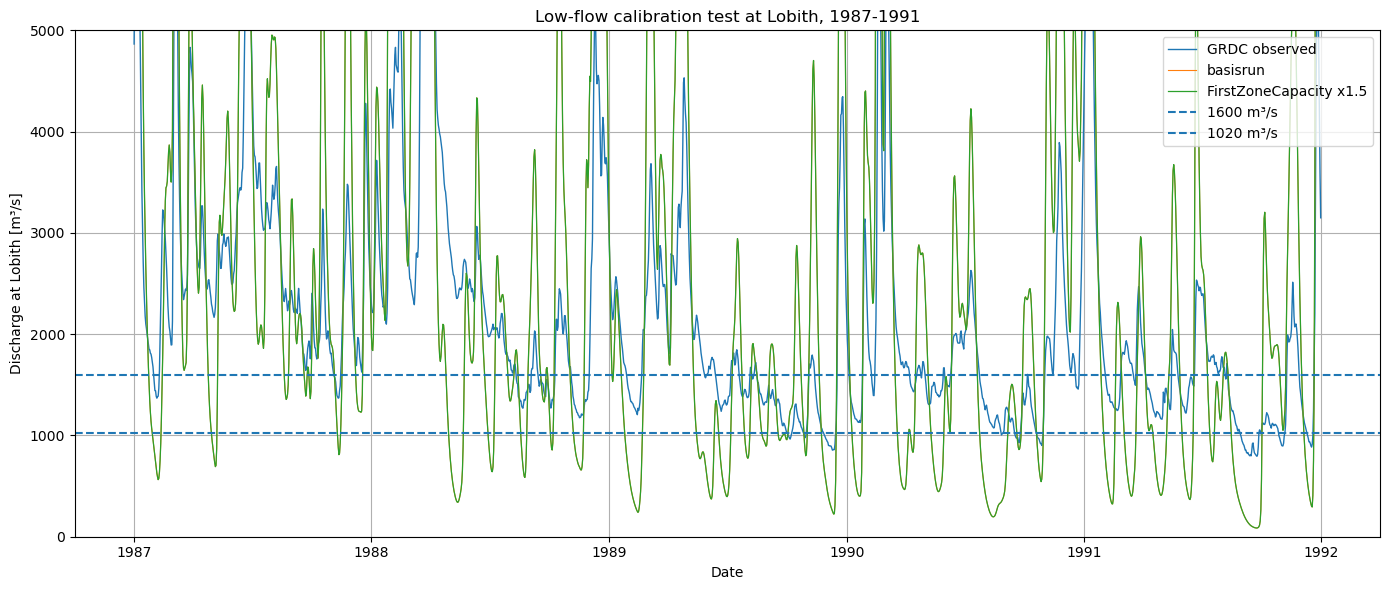

In [33]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison_lowflow_1["date"],
    comparison_lowflow_1["Q_grdc_m3s"],
    label="GRDC observed",
    linewidth=1.0
)

plt.plot(
    comparison_lowflow_1["date"],
    comparison_lowflow_1["Q_basis_m3s"],
    label="basisrun",
    linewidth=0.8
)

plt.plot(
    comparison_lowflow_1["date"],
    comparison_lowflow_1["Q_lowflow_1_m3s"],
    label="FirstZoneCapacity x1.5",
    linewidth=0.9
)

plt.axhline(1600, linestyle="--", label="1600 m³/s")
plt.axhline(1020, linestyle="--", label="1020 m³/s")

plt.ylim(0, 5000)

plt.xlabel("Date")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title("Low-flow calibration test at Lobith, 1987-1991")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
verschil = comparison_lowflow_1["Q_lowflow_1_m3s"] - comparison_lowflow_1["Q_basis_m3s"]

print("Max absoluut verschil:", verschil.abs().max())
print("Gemiddeld verschil:", verschil.mean())
print("Aantal dagen met verschil:", (verschil.abs() > 0.0001).sum())

Max absoluut verschil: 2.2737367544323206e-13
Gemiddeld verschil: 8.949881118555479e-16
Aantal dagen met verschil: 0


In [35]:
factors = {
    "FirstZoneCapacity.tbl": 1.5
}

model_fzc15 = run_calibration_model(
    run_name="test_fzc15_1987_1991",
    factors=factors
)

Runmap aangemaakt:
/home/niels/BEP-Niels/temp_runs/run_test_fzc15_1987_1991

Parameters vóór aanpassing:

Parameter: FirstZoneCapacity.tbl
Aantal bestanden gevonden: 1
intbl/FirstZoneCapacity.tbl
min: 400.0 max: 24000.0 mean: 7830.95
Aanpassen: intbl/FirstZoneCapacity.tbl factor: 1.5

Parameters na aanpassing:

Parameter: FirstZoneCapacity.tbl
Aantal bestanden gevonden: 1
intbl/FirstZoneCapacity.tbl
min: 600.0 max: 36000.0 mean: 11746.43
Stap: 365 Tijd: 1986-12-31 00:00:00 Q: 11876.8
Stap: 730 Tijd: 1987-12-31 00:00:00 Q: 2224.0
Stap: 1095 Tijd: 1988-12-30 00:00:00 Q: 3958.7
Stap: 1460 Tijd: 1989-12-30 00:00:00 Q: 4676.8
Stap: 1825 Tijd: 1990-12-30 00:00:00 Q: 6410.8
Stap: 2190 Tijd: 1991-12-30 00:00:00 Q: 7189.5

Run klaar: test_fzc15_1987_1991
Aantal dagen: 1826
Opgeslagen als: /home/niels/BEP-Niels/results/test_fzc15_1987_1991_lobith_daily.csv


In [36]:
model_fzc15 = model_fzc15.rename(
    columns={"Q_model_m3s": "Q_fzc15_m3s"}
)

comparison_fzc15 = pd.merge(
    comparison,
    model_fzc15[["date", "Q_fzc15_m3s"]],
    on="date",
    how="inner"
)

In [37]:
verschil = comparison_fzc15["Q_fzc15_m3s"] - comparison_fzc15["Q_basis_m3s"]

print("Max absoluut verschil:", verschil.abs().max())
print("Gemiddeld verschil:", verschil.mean())
print("Aantal dagen met verschil:", (verschil.abs() > 0.0001).sum())

Max absoluut verschil: 2.2737367544323206e-13
Gemiddeld verschil: 8.949881118555479e-16
Aantal dagen met verschil: 0


In [38]:
maxleakage_file = Path(parameter_set.directory) / "intbl" / "MaxLeakage.tbl"

print(maxleakage_file)
print(maxleakage_file.exists())
print(maxleakage_file.read_text())

/data/shared/parameter-sets/wflow_rhine_sbm_nc/intbl/MaxLeakage.tbl
True
<,10]	<,14]	1 0.0



In [39]:
values = get_tbl_last_column_values(maxleakage_file)

print("Aantal waarden:", len(values))
print("Min:", min(values))
print("Max:", max(values))
print("Mean:", np.mean(values))
print("Aantal waarden groter dan 0:", sum(v > 0 for v in values))

Aantal waarden: 1
Min: 0.0
Max: 0.0
Mean: 0.0
Aantal waarden groter dan 0: 0


In [40]:
factors = {
    "M.tbl": 1.5
}

In [41]:
m_file = Path(parameter_set.directory) / "intbl" / "M.tbl"

print(m_file)
print(m_file.exists())
print(m_file.read_text())

/data/shared/parameter-sets/wflow_rhine_sbm_nc/intbl/M.tbl
True
<,7]	1	1 1504
<,7]	2	1 193
<,7]	3	1 12880
<,7]	4	1 183
<,7]	5	1 176
<,7]	6	1 183
<,7]	7	1 133
<,7]	8	1 1450	
<,7]	9	1 183
<,7]	10	1  190
<,7]	11	1  1100
<,7]	12	1  17
<,7]	13	1  128
<,7]	14	1  17


In [42]:
values = get_tbl_last_column_values(m_file)

print("Aantal waarden:", len(values))
print("Min:", min(values))
print("Max:", max(values))
print("Mean:", np.mean(values))

Aantal waarden: 14
Min: 17.0
Max: 12880.0
Mean: 1309.7857142857142


In [43]:
factors = {
    "M.tbl": 1.5
}

model_m15 = run_calibration_model(
    run_name="test_M_x15_1987_1991",
    factors=factors
)

Runmap aangemaakt:
/home/niels/BEP-Niels/temp_runs/run_test_M_x15_1987_1991

Parameters vóór aanpassing:

Parameter: M.tbl
Aantal bestanden gevonden: 1
intbl/M.tbl
min: 17.0 max: 12880.0 mean: 1309.79
Aanpassen: intbl/M.tbl factor: 1.5

Parameters na aanpassing:

Parameter: M.tbl
Aantal bestanden gevonden: 1
intbl/M.tbl
min: 25.5 max: 19320.0 mean: 1964.68
Stap: 365 Tijd: 1986-12-31 00:00:00 Q: 11876.8
Stap: 730 Tijd: 1987-12-31 00:00:00 Q: 2224.0
Stap: 1095 Tijd: 1988-12-30 00:00:00 Q: 3958.0
Stap: 1460 Tijd: 1989-12-30 00:00:00 Q: 4674.7
Stap: 1825 Tijd: 1990-12-30 00:00:00 Q: 6402.7
Stap: 2190 Tijd: 1991-12-30 00:00:00 Q: 7189.0

Run klaar: test_M_x15_1987_1991
Aantal dagen: 1826
Opgeslagen als: /home/niels/BEP-Niels/results/test_M_x15_1987_1991_lobith_daily.csv


In [44]:
model_m15 = model_m15.rename(
    columns={"Q_model_m3s": "Q_M15_m3s"}
)

comparison_m15 = pd.merge(
    comparison,
    model_m15[["date", "Q_M15_m3s"]],
    on="date",
    how="inner"
)

comparison_m15.head()

,date,Q_grdc_m3s,Q_basis_m3s,Q_M15_m3s
0,1987-01-01,4865.0,13869.678711,13869.695312
1,1987-01-02,5756.0,15741.568359,15741.561523
2,1987-01-03,6160.0,16061.675781,16061.661133
3,1987-01-04,6973.0,15124.300781,15124.301758
4,1987-01-05,7579.0,13978.630859,13978.650391


In [45]:
verschil = comparison_m15["Q_M15_m3s"] - comparison_m15["Q_basis_m3s"]

print("Max absoluut verschil:", verschil.abs().max())
print("Gemiddeld verschil:", verschil.mean())
print("Aantal dagen met verschil:", (verschil.abs() > 0.0001).sum())

Max absoluut verschil: 40.21630859375
Gemiddeld verschil: -0.5419921373615904
Aantal dagen met verschil: 1824


In [46]:
model_columns = {
    "basisrun": "Q_basis_m3s",
    "M_x1.5": "Q_M15_m3s"
}

score_all = make_score_table(
    comparison_m15,
    model_columns
)

score_low = make_score_table(
    comparison_m15[
        comparison_m15["Q_grdc_m3s"] < 1600
    ],
    model_columns
)

score_all

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,basisrun,582.0,1876.4,-1.042,1826
1,M_x1.5,581.4,1875.2,-1.040,1826


In [47]:
score_low

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,basisrun,-147.0,740.8,-21.205,669
1,M_x1.5,-146.7,740.8,-21.196,669


In [48]:
infilt_file = Path(parameter_set.directory) / "intbl" / "InfiltCapSoil.tbl"

print(infilt_file)
print(infilt_file.exists())
print(infilt_file.read_text())

/data/shared/parameter-sets/wflow_rhine_sbm_nc/intbl/InfiltCapSoil.tbl
True
1 <,14]	1 5000
2 <,14]	1 5000
3 <,14]	1 5000
4 <,14]	1 5000
5 <,14]	1 5000
6 <,14]	1 5000


In [49]:
values = get_tbl_last_column_values(infilt_file)

print("Aantal waarden:", len(values))
print("Min:", min(values))
print("Max:", max(values))
print("Mean:", np.mean(values))

Aantal waarden: 6
Min: 5000.0
Max: 5000.0
Mean: 5000.0


In [50]:
factors = {
    "InfiltCapSoil.tbl": 1.5
}

model_infilt15 = run_calibration_model(
    run_name="test_InfiltCapSoil_x15_1987_1991",
    factors=factors
)

Runmap aangemaakt:
/home/niels/BEP-Niels/temp_runs/run_test_InfiltCapSoil_x15_1987_1991

Parameters vóór aanpassing:

Parameter: InfiltCapSoil.tbl
Aantal bestanden gevonden: 1
intbl/InfiltCapSoil.tbl
min: 5000.0 max: 5000.0 mean: 5000.0
Aanpassen: intbl/InfiltCapSoil.tbl factor: 1.5

Parameters na aanpassing:

Parameter: InfiltCapSoil.tbl
Aantal bestanden gevonden: 1
intbl/InfiltCapSoil.tbl
min: 7500.0 max: 7500.0 mean: 7500.0
Stap: 365 Tijd: 1986-12-31 00:00:00 Q: 11876.8
Stap: 730 Tijd: 1987-12-31 00:00:00 Q: 2224.0
Stap: 1095 Tijd: 1988-12-30 00:00:00 Q: 3958.7
Stap: 1460 Tijd: 1989-12-30 00:00:00 Q: 4676.8
Stap: 1825 Tijd: 1990-12-30 00:00:00 Q: 6410.8
Stap: 2190 Tijd: 1991-12-30 00:00:00 Q: 7189.5

Run klaar: test_InfiltCapSoil_x15_1987_1991
Aantal dagen: 1826
Opgeslagen als: /home/niels/BEP-Niels/results/test_InfiltCapSoil_x15_1987_1991_lobith_daily.csv


In [51]:
model_infilt15 = model_infilt15.rename(
    columns={"Q_model_m3s": "Q_Infilt15_m3s"}
)

comparison_infilt15 = pd.merge(
    comparison,
    model_infilt15[["date", "Q_Infilt15_m3s"]],
    on="date",
    how="inner"
)

In [52]:
verschil = comparison_infilt15["Q_Infilt15_m3s"] - comparison_infilt15["Q_basis_m3s"]

print("Max absoluut verschil:", verschil.abs().max())
print("Gemiddeld verschil:", verschil.mean())
print("Aantal dagen met verschil:", (verschil.abs() > 0.0001).sum())

Max absoluut verschil: 2.2737367544323206e-13
Gemiddeld verschil: 8.949881118555479e-16
Aantal dagen met verschil: 0


In [53]:
ksat_file = Path(parameter_set.directory) / "intbl" / "FirstZoneKsatVer.tbl"

print(ksat_file)
print(ksat_file.exists())
print(ksat_file.read_text())

/data/shared/parameter-sets/wflow_rhine_sbm_nc/intbl/FirstZoneKsatVer.tbl
True
<,7]	1  1  8000
<,7]	2  1  100
<,7]	3  1  100
<,7]	4  1  1000
<,7]	5  1  1000
<,7]	6  1  1000
<,7]	7  1  1500
<,7]	8  1  100
<,7]	9  1  1000
<,7]	10 1  1000
<,7]	11 1  750
<,7]	12 1  4000
<,7]	13 1  1500
<,7]	14 1  8000


In [54]:
values = get_tbl_last_column_values(ksat_file)

print("Aantal waarden:", len(values))
print("Min:", min(values))
print("Max:", max(values))
print("Mean:", np.mean(values))

Aantal waarden: 14
Min: 100.0
Max: 8000.0
Mean: 2075.0


In [55]:
factors = {
    "FirstZoneKsatVer.tbl": 0.5
}

model_ksat05 = run_calibration_model(
    run_name="test_FirstZoneKsatVer_x05_1987_1991",
    factors=factors
)

Runmap aangemaakt:
/home/niels/BEP-Niels/temp_runs/run_test_FirstZoneKsatVer_x05_1987_1991

Parameters vóór aanpassing:

Parameter: FirstZoneKsatVer.tbl
Aantal bestanden gevonden: 1
intbl/FirstZoneKsatVer.tbl
min: 100.0 max: 8000.0 mean: 2075.0
Aanpassen: intbl/FirstZoneKsatVer.tbl factor: 0.5

Parameters na aanpassing:

Parameter: FirstZoneKsatVer.tbl
Aantal bestanden gevonden: 1
intbl/FirstZoneKsatVer.tbl
min: 50.0 max: 4000.0 mean: 1037.5
Stap: 365 Tijd: 1986-12-31 00:00:00 Q: 11876.8
Stap: 730 Tijd: 1987-12-31 00:00:00 Q: 2224.0
Stap: 1095 Tijd: 1988-12-30 00:00:00 Q: 3958.7
Stap: 1460 Tijd: 1989-12-30 00:00:00 Q: 4676.8
Stap: 1825 Tijd: 1990-12-30 00:00:00 Q: 6410.8
Stap: 2190 Tijd: 1991-12-30 00:00:00 Q: 7189.5

Run klaar: test_FirstZoneKsatVer_x05_1987_1991
Aantal dagen: 1826
Opgeslagen als: /home/niels/BEP-Niels/results/test_FirstZoneKsatVer_x05_1987_1991_lobith_daily.csv


In [56]:
model_ksat05 = model_ksat05.rename(
    columns={"Q_model_m3s": "Q_Ksat05_m3s"}
)

comparison_ksat05 = pd.merge(
    comparison,
    model_ksat05[["date", "Q_Ksat05_m3s"]],
    on="date",
    how="inner"
)

In [57]:
verschil = comparison_ksat05["Q_Ksat05_m3s"] - comparison_ksat05["Q_basis_m3s"]

print("Max absoluut verschil:", verschil.abs().max())
print("Gemiddeld verschil:", verschil.mean())
print("Aantal dagen met verschil:", (verschil.abs() > 0.0001).sum())

Max absoluut verschil: 2.2737367544323206e-13
Gemiddeld verschil: 8.949881118555479e-16
Aantal dagen met verschil: 0


In [58]:
inspect_dir = temp_dir / "run_inspect_parameters"

if inspect_dir.exists():
    shutil.rmtree(inspect_dir)

model_inspect = Wflow(
    parameter_set=parameter_set,
    forcing=forcing
)

cfg_file_inspect, cfg_dir_inspect = model_inspect.setup(
    cfg_dir=str(inspect_dir)
)

cfg_file_inspect = Path(cfg_file_inspect)
cfg_dir_inspect = Path(cfg_dir_inspect)

print("Config file:", cfg_file_inspect)
print("Run directory:", cfg_dir_inspect)

Config file: /home/niels/BEP-Niels/temp_runs/run_inspect_parameters/wflow_ewatercycle.ini
Run directory: /home/niels/BEP-Niels/temp_runs/run_inspect_parameters


In [59]:
config_text = cfg_file_inspect.read_text()

zoekwoorden = [
    "tbl",
    "intbl",
    "FirstZone",
    "Ksat",
    "Infilt",
    "Leakage",
    "Rooting",
    "theta",
    "N_",
    "River",
    "M",
    "Cfmax",
    "Max"
]

for line in config_text.splitlines():
    line_lower = line.lower()
    
    if any(woord.lower() in line_lower for woord in zoekwoorden):
        print(line)

[inputmapstacks]
Temperature = /tas
Inflow = /inmaps/IF
[modelparameters]
starttime = 1986-01-01 00:00:00
endtime = 1992-01-01 00:00:00
timestepsecs = 86400
[model]
modeltype = sbm
ModelSnow = 0
InterpolationMethod = inv
WIMaxScale = 0.8
UpdMaxDist = 300000.0
[misc]
[framework]
netcdfoutput = outmaps.nc
sizeinmetres = 0
[outputmaps]
self.RiverRunoff = run
self.InwaterMM = iwm
[summary]
self.MaxLeakage = MaxLeakage.map
[summary_sum]
self.Precipitation = Sumprecip.map
[summary_max]
self.Precipitation = maxprecip.map
[summary_min]
[summary_avg]
self.Precipitation = avgprecip.map
samplemap = staticmaps/wflow_landuse.map
samplemap = staticmaps/wflow_gauges.map
self.RiverRunoff = run.tss
samplemap = staticmaps/wflow_gauges.map
self.ActLeakage = lek.tss
RiverRunoff = 2, m/s


In [60]:
tbl_files = sorted(cfg_dir_inspect.rglob("*.tbl"))

print("Aantal tbl-bestanden:", len(tbl_files))

rows = []

for tbl_file in tbl_files:
    values = get_tbl_last_column_values(tbl_file)
    
    if len(values) > 0:
        rows.append({
            "file": str(tbl_file.relative_to(cfg_dir_inspect)),
            "n_values": len(values),
            "min": min(values),
            "max": max(values),
            "mean": np.mean(values)
        })

tbl_summary = pd.DataFrame(rows)
tbl_summary

Aantal tbl-bestanden: 22


,file,n_values,min,max,mean
0,intbl/CanopyGapFraction.tbl,6,0.10000,0.80000,0.583333
1,intbl/Cfmax.tbl,1,3.75653,3.75653,3.756530
2,intbl/EoverR.tbl,6,0.11000,0.15000,0.116667
3,intbl/FirstZoneCapacity.tbl,84,400.00000,24000.00000,7830.952381
4,intbl/FirstZoneKsatVer.tbl,14,100.00000,8000.00000,2075.000000
5,intbl/FirstZoneMinCapacity.tbl,84,20.00000,350.00000,232.559524
6,intbl/InfiltCapPath.tbl,6,5.00000,5.00000,5.000000
7,intbl/InfiltCapSoil.tbl,6,5000.00000,5000.00000,5000.000000
8,intbl/M.tbl,14,17.00000,12880.00000,1309.785714
9,intbl/MaxCanopyStorage.tbl,6,0.00100,1.20000,0.292000


In [61]:
tbl_summary[
    tbl_summary["file"].str.contains(
        "FirstZone|Ksat|Infilt|Leakage|Root|theta|M|N|River",
        case=False,
        regex=True
    )
]

,file,n_values,min,max,mean
0,intbl/CanopyGapFraction.tbl,6,0.10000,0.80000,0.583333
1,intbl/Cfmax.tbl,1,3.75653,3.75653,3.756530
2,intbl/EoverR.tbl,6,0.11000,0.15000,0.116667
3,intbl/FirstZoneCapacity.tbl,84,400.00000,24000.00000,7830.952381
4,intbl/FirstZoneKsatVer.tbl,14,100.00000,8000.00000,2075.000000
5,intbl/FirstZoneMinCapacity.tbl,84,20.00000,350.00000,232.559524
6,intbl/InfiltCapPath.tbl,6,5.00000,5.00000,5.000000
7,intbl/InfiltCapSoil.tbl,6,5000.00000,5000.00000,5000.000000
8,intbl/M.tbl,14,17.00000,12880.00000,1309.785714
9,intbl/MaxCanopyStorage.tbl,6,0.00100,1.20000,0.292000


In [62]:
for line in config_text.splitlines():
    if "=" in line:
        key, value = line.split("=", 1)
        
        value = value.strip()
        
        if any(ext in value for ext in [".tbl", ".map", ".nc", ".csv"]):
            print(line)

netcdfoutput = outmaps.nc
netcdfinput = wflow_ERA5_Rhine_1986_1995.nc
self.MaxLeakage = MaxLeakage.map
self.Precipitation = Sumprecip.map
self.Precipitation = maxprecip.map
self.Precipitation = avgprecip.map
samplemap = staticmaps/wflow_landuse.map
self.Transfer = tra_lu.csv
samplemap = staticmaps/wflow_gauges.map
samplemap = staticmaps/wflow_gauges.map


In [63]:
static_nc = cfg_dir_inspect / "staticmaps.nc"

ds = xr.open_dataset(static_nc)

print("Variabelen in staticmaps.nc:")

for var in ds.data_vars:
    print(var)

ds.close()

Variabelen in staticmaps.nc:
crs
wflow_bankfulldepth.map
wflow_catchment.map
wflow_dem.map
wflow_dem10.map
wflow_dem25.map
wflow_dem33.map
wflow_dem66.map
wflow_dem75.map
wflow_dem90.map
wflow_demmax.map
wflow_demmin.map
wflow_gauges.map
wflow_landuse.map
wflow_ldd.map
wflow_outlet.map
wflow_river.map
wflow_riverburnin.map
wflow_riverdem.map
wflow_riverlength_fact.map
wflow_soil.map
wflow_streamorder.map
wflow_subcatch.map


In [64]:
ds = xr.open_dataset(static_nc)

rows = []

for var in ds.data_vars:
    data = ds[var]
    
    try:
        values = data.values
        values = values[np.isfinite(values)]
        
        if values.size > 0:
            rows.append({
                "variable": var,
                "min": float(values.min()),
                "max": float(values.max()),
                "mean": float(values.mean())
            })
    except:
        pass

ds.close()

static_summary = pd.DataFrame(rows)
static_summary

,variable,min,max,mean
0,wflow_bankfulldepth.map,0.203521,99999.000000,95398.382812
1,wflow_catchment.map,0.000000,1.000000,0.498497
2,wflow_dem.map,1.328606,4004.066650,596.836426
3,wflow_dem10.map,0.235573,3807.011475,555.421814
4,wflow_dem25.map,0.742026,3893.656738,572.306519
5,wflow_dem33.map,0.906034,3930.636963,580.402771
6,wflow_dem66.map,1.689794,4065.198486,612.152954
7,wflow_dem75.map,1.994452,4101.097168,621.645020
8,wflow_dem90.map,2.513818,4166.764160,640.358154
9,wflow_demmax.map,2.513818,4166.764160,640.358154


In [65]:
config_text = cfg_file_inspect.read_text()

for line in config_text.splitlines():
    if "tbl" in line.lower() or "intbl" in line.lower():
        print(line)

In [66]:
zoekwoorden = [
    "FirstZoneCapacity",
    "FirstZoneKsatVer",
    "InfiltCapSoil",
    "RootingDepth",
    "thetaS",
    "thetaR",
    "M",
    "N_River",
    "Cfmax",
    "TT",
    "WHC"
]

for woord in zoekwoorden:
    print("\n---", woord, "---")
    
    gevonden = False
    
    for line in config_text.splitlines():
        if woord.lower() in line.lower():
            print(line)
            gevonden = True
    
    if not gevonden:
        print("Niet gevonden")


--- FirstZoneCapacity ---
Niet gevonden

--- FirstZoneKsatVer ---
Niet gevonden

--- InfiltCapSoil ---
Niet gevonden

--- RootingDepth ---
Niet gevonden

--- thetaS ---
Niet gevonden

--- thetaR ---
Niet gevonden

--- M ---
[inputmapstacks]
Temperature = /tas
Inflow = /inmaps/IF
[modelparameters]
starttime = 1986-01-01 00:00:00
endtime = 1992-01-01 00:00:00
timestepsecs = 86400
[model]
modeltype = sbm
ModelSnow = 0
InterpolationMethod = inv
WIMaxScale = 0.8
UpdMaxDist = 300000.0
[misc]
[framework]
netcdfoutput = outmaps.nc
sizeinmetres = 0
[outputmaps]
self.InwaterMM = iwm
[summary]
self.MaxLeakage = MaxLeakage.map
[summary_sum]
self.Precipitation = Sumprecip.map
[summary_max]
self.Precipitation = maxprecip.map
[summary_min]
[summary_avg]
self.Precipitation = avgprecip.map
samplemap = staticmaps/wflow_landuse.map
samplemap = staticmaps/wflow_gauges.map
samplemap = staticmaps/wflow_gauges.map
RiverRunoff = 2, m/s

--- N_River ---
Niet gevonden

--- Cfmax ---
Niet gevonden

--- TT ---
s

In [67]:
for file in sorted(results_dir.glob("*.csv")):
    print(file.name)

basisrun_1987_1995_lobith_daily.csv
lobith_model_point_wflow.csv
lowflow_FirstZoneCapacity_x15_1987_1991_lobith_daily.csv
lowflow_storage_leakage_1_lobith_daily.csv
test_FirstZoneKsatVer_x05_1987_1991_lobith_daily.csv
test_InfiltCapSoil_x15_1987_1991_lobith_daily.csv
test_M_x15_1987_1991_lobith_daily.csv
test_fzc15_1987_1991_lobith_daily.csv
wflow_lobith_1991_daily.csv
wflow_lobith_1992_daily.csv


In [68]:
for file in sorted(results_dir.glob("*.csv")):
    name = file.name.lower()
    
    if ("root" in name) or ("river" in name) or ("n_river" in name) or ("nriver" in name):
        print(file)

In [69]:
for folder in sorted(temp_dir.glob("run_*")):
    name = folder.name.lower()
    
    if ("root" in name) or ("river" in name) or ("n_river" in name) or ("nriver" in name):
        print(folder)

In [70]:
run_files = {
    "basisrun": results_dir / "basisrun_1987_1995_lobith_daily.csv",
    "FZC_x1.5": results_dir / "test_fzc15_1987_1991_lobith_daily.csv",
    "M_x1.5": results_dir / "test_M_x15_1987_1991_lobith_daily.csv",
    "Infilt_x1.5": results_dir / "test_InfiltCapSoil_x15_1987_1991_lobith_daily.csv",
    "Ksat_x0.5": results_dir / "test_FirstZoneKsatVer_x05_1987_1991_lobith_daily.csv",
    "storage_leakage": results_dir / "lowflow_storage_leakage_1_lobith_daily.csv",
}

for name, file in run_files.items():
    print(name, file.exists(), file.name)

basisrun True basisrun_1987_1995_lobith_daily.csv
FZC_x1.5 True test_fzc15_1987_1991_lobith_daily.csv
M_x1.5 True test_M_x15_1987_1991_lobith_daily.csv
Infilt_x1.5 True test_InfiltCapSoil_x15_1987_1991_lobith_daily.csv
Ksat_x0.5 True test_FirstZoneKsatVer_x05_1987_1991_lobith_daily.csv
storage_leakage True lowflow_storage_leakage_1_lobith_daily.csv


In [71]:
comparison_all_runs = grdc_calibration.copy()

model_columns = {}

for run_name, file in run_files.items():
    if not file.exists():
        print("Bestand niet gevonden:", run_name, file)
        continue
    
    temp = pd.read_csv(file)
    temp["date"] = pd.to_datetime(temp["date"])
    
    # Alleen huidige kalibratieperiode gebruiken
    temp = temp[
        (temp["date"] >= calibration_start) &
        (temp["date"] <= calibration_end)
    ].copy()
    
    q_col = f"Q_{run_name}_m3s"
    
    temp = temp.rename(columns={"Q_model_m3s": q_col})
    temp = temp[["date", q_col]]
    
    comparison_all_runs = pd.merge(
        comparison_all_runs,
        temp,
        on="date",
        how="inner"
    )
    
    model_columns[run_name] = q_col
    
    print(run_name)
    print("  start:", temp["date"].min())
    print("  einde:", temp["date"].max())
    print("  dagen:", len(temp))

print("Aantal dagen in gecombineerde vergelijking:", len(comparison_all_runs))
comparison_all_runs.head()

basisrun
  start: 1987-01-01 00:00:00
  einde: 1991-12-31 00:00:00
  dagen: 1826
FZC_x1.5
  start: 1987-01-01 00:00:00
  einde: 1991-12-31 00:00:00
  dagen: 1826
M_x1.5
  start: 1987-01-01 00:00:00
  einde: 1991-12-31 00:00:00
  dagen: 1826
Infilt_x1.5
  start: 1987-01-01 00:00:00
  einde: 1991-12-31 00:00:00
  dagen: 1826
Ksat_x0.5
  start: 1987-01-01 00:00:00
  einde: 1991-12-31 00:00:00
  dagen: 1826
storage_leakage
  start: 1987-01-01 00:00:00
  einde: 1991-12-31 00:00:00
  dagen: 1826
Aantal dagen in gecombineerde vergelijking: 1826


,date,Q_grdc_m3s,Q_basisrun_m3s,Q_FZC_x1.5_m3s,Q_M_x1.5_m3s,Q_Infilt_x1.5_m3s,Q_Ksat_x0.5_m3s,Q_storage_leakage_m3s
0,1987-01-01,4865.0,13869.678711,13869.678711,13869.695312,13869.678711,13869.678711,13869.678711
1,1987-01-02,5756.0,15741.568359,15741.568359,15741.561523,15741.568359,15741.568359,15741.568359
2,1987-01-03,6160.0,16061.675781,16061.675781,16061.661133,16061.675781,16061.675781,16061.675781
3,1987-01-04,6973.0,15124.300781,15124.300781,15124.301758,15124.300781,15124.300781,15124.300781
4,1987-01-05,7579.0,13978.630859,13978.630859,13978.650391,13978.630859,13978.630859,13978.630859


In [72]:
score_all = make_score_table(
    comparison_all_runs,
    model_columns
)

score_all

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,basisrun,582.0,1876.4,-1.042,1826
1,FZC_x1.5,582.0,1876.4,-1.042,1826
2,M_x1.5,581.4,1875.2,-1.040,1826
3,Infilt_x1.5,582.0,1876.4,-1.042,1826
4,Ksat_x0.5,582.0,1876.4,-1.042,1826
5,storage_leakage,582.0,1876.4,-1.042,1826


In [73]:
threshold_table = []

for run_name, q_col in model_columns.items():
    threshold_table.append({
        "run": run_name,
        "days_below_1600": (comparison_all_runs[q_col] < 1600).sum(),
        "days_below_1020": (comparison_all_runs[q_col] < 1020).sum()
    })

threshold_table = pd.DataFrame(threshold_table)
threshold_table

,run,days_below_1600,days_below_1020
0,basisrun,760,485
1,FZC_x1.5,760,485
2,M_x1.5,760,485
3,Infilt_x1.5,760,485
4,Ksat_x0.5,760,485
5,storage_leakage,760,485


In [74]:
print("GRDC dagen < 1600:", (comparison_all_runs["Q_grdc_m3s"] < 1600).sum())
print("GRDC dagen < 1020:", (comparison_all_runs["Q_grdc_m3s"] < 1020).sum())

GRDC dagen < 1600: 669
GRDC dagen < 1020: 96


In [75]:
for tbl_name in ["EoverR.tbl", "RootingDepth.tbl"]:
    tbl_file = Path(parameter_set.directory) / "intbl" / tbl_name
    
    print("\n---", tbl_name, "---")
    print("Bestaat:", tbl_file.exists())
    
    values = get_tbl_last_column_values(tbl_file)
    
    print("Aantal waarden:", len(values))
    print("Min:", min(values))
    print("Max:", max(values))
    print("Mean:", round(np.mean(values), 4))


--- EoverR.tbl ---
Bestaat: True
Aantal waarden: 6
Min: 0.11
Max: 0.15
Mean: 0.1167

--- RootingDepth.tbl ---
Bestaat: True
Aantal waarden: 84
Min: 2.0
Max: 525.0
Mean: 107.881


In [76]:
factors = {
    "EoverR.tbl": 0.5,
    "RootingDepth.tbl": 0.75
}

model_et_lowflow = run_calibration_model(
    run_name="test_EoverR_x05_RootDepth_x075_1987_1991",
    factors=factors
)

Runmap aangemaakt:
/home/niels/BEP-Niels/temp_runs/run_test_EoverR_x05_RootDepth_x075_1987_1991

Parameters vóór aanpassing:

Parameter: EoverR.tbl
Aantal bestanden gevonden: 1
intbl/EoverR.tbl
min: 0.11 max: 0.15 mean: 0.12

Parameter: RootingDepth.tbl
Aantal bestanden gevonden: 1
intbl/RootingDepth.tbl
min: 2.0 max: 525.0 mean: 107.88
Aanpassen: intbl/EoverR.tbl factor: 0.5
Aanpassen: intbl/RootingDepth.tbl factor: 0.75

Parameters na aanpassing:

Parameter: EoverR.tbl
Aantal bestanden gevonden: 1
intbl/EoverR.tbl
min: 0.055 max: 0.075 mean: 0.06

Parameter: RootingDepth.tbl
Aantal bestanden gevonden: 1
intbl/RootingDepth.tbl
min: 1.5 max: 393.75 mean: 80.91
Stap: 365 Tijd: 1986-12-31 00:00:00 Q: 11898.7
Stap: 730 Tijd: 1987-12-31 00:00:00 Q: 2231.5
Stap: 1095 Tijd: 1988-12-30 00:00:00 Q: 3993.6
Stap: 1460 Tijd: 1989-12-30 00:00:00 Q: 4737.9
Stap: 1825 Tijd: 1990-12-30 00:00:00 Q: 6620.2
Stap: 2190 Tijd: 1991-12-30 00:00:00 Q: 7364.9

Run klaar: test_EoverR_x05_RootDepth_x075_1987_19

In [77]:
model_et_lowflow = model_et_lowflow.rename(
    columns={"Q_model_m3s": "Q_ET_lowflow_m3s"}
)

comparison_et = pd.merge(
    comparison,
    model_et_lowflow[["date", "Q_ET_lowflow_m3s"]],
    on="date",
    how="inner"
)

comparison_et.head()

,date,Q_grdc_m3s,Q_basis_m3s,Q_ET_lowflow_m3s
0,1987-01-01,4865.0,13869.678711,13890.761719
1,1987-01-02,5756.0,15741.568359,15760.574219
2,1987-01-03,6160.0,16061.675781,16078.226562
3,1987-01-04,6973.0,15124.300781,15139.417969
4,1987-01-05,7579.0,13978.630859,13992.887695


In [78]:
verschil = comparison_et["Q_ET_lowflow_m3s"] - comparison_et["Q_basis_m3s"]

print("Max absoluut verschil:", verschil.abs().max())
print("Gemiddeld verschil:", verschil.mean())
print("Aantal dagen met verschil:", (verschil.abs() > 0.0001).sum())

Max absoluut verschil: 922.056640625
Gemiddeld verschil: 61.38121463487339
Aantal dagen met verschil: 1826


In [79]:
model_columns = {
    "basisrun": "Q_basis_m3s",
    "ET_lowflow": "Q_ET_lowflow_m3s"
}

score_all = make_score_table(
    comparison_et,
    model_columns
)

score_low = make_score_table(
    comparison_et[
        comparison_et["Q_grdc_m3s"] < 1600
    ],
    model_columns
)

score_all

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,basisrun,582.0,1876.4,-1.042,1826
1,ET_lowflow,643.3,1926.6,-0.993,1826


In [80]:
threshold_table = []

for run_name, q_col in model_columns.items():
    threshold_table.append({
        "run": run_name,
        "days_below_1600": (comparison_et[q_col] < 1600).sum(),
        "days_below_1020": (comparison_et[q_col] < 1020).sum()
    })

threshold_table = pd.DataFrame(threshold_table)

print("GRDC dagen < 1600:", (comparison_et["Q_grdc_m3s"] < 1600).sum())
print("GRDC dagen < 1020:", (comparison_et["Q_grdc_m3s"] < 1020).sum())

threshold_table

GRDC dagen < 1600: 669
GRDC dagen < 1020: 96


,run,days_below_1600,days_below_1020
0,basisrun,760,485
1,ET_lowflow,737,458


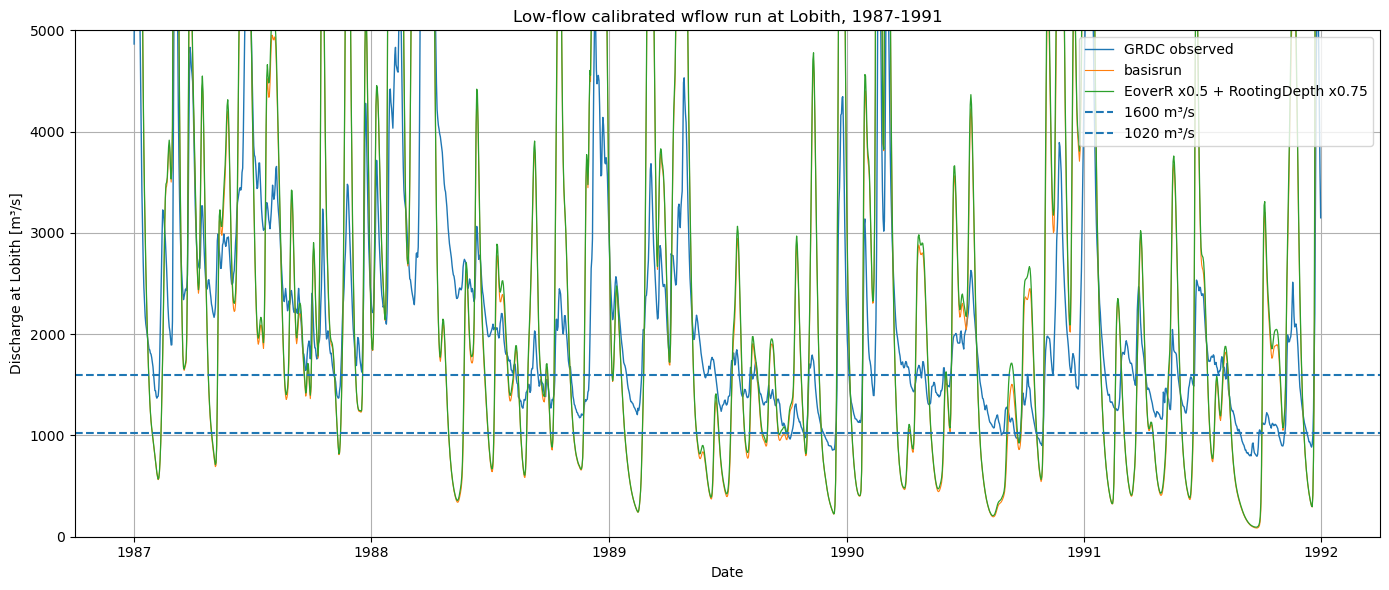

In [81]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison_et["date"],
    comparison_et["Q_grdc_m3s"],
    label="GRDC observed",
    linewidth=1.0
)

plt.plot(
    comparison_et["date"],
    comparison_et["Q_basis_m3s"],
    label="basisrun",
    linewidth=0.8
)

plt.plot(
    comparison_et["date"],
    comparison_et["Q_ET_lowflow_m3s"],
    label="EoverR x0.5 + RootingDepth x0.75",
    linewidth=0.9
)

plt.axhline(1600, linestyle="--", label="1600 m³/s")
plt.axhline(1020, linestyle="--", label="1020 m³/s")

plt.ylim(0, 5000)

plt.xlabel("Date")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title("Low-flow calibrated wflow run at Lobith, 1987-1991")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [82]:
score_low

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,basisrun,-147.0,740.8,-21.205,669
1,ET_lowflow,-104.1,757.7,-20.127,669


In [83]:
factors = {
    "EoverR.tbl": 0.5,
    "RootingDepth.tbl": 0.75,
    "N_River.tbl": 2.0
}

model_calibrated_1 = run_calibration_model(
    run_name="calibrated_ET_Root_NRiver_1987_1991",
    factors=factors
)

Runmap aangemaakt:
/home/niels/BEP-Niels/temp_runs/run_calibrated_ET_Root_NRiver_1987_1991

Parameters vóór aanpassing:

Parameter: EoverR.tbl
Aantal bestanden gevonden: 1
intbl/EoverR.tbl
min: 0.11 max: 0.15 mean: 0.12

Parameter: RootingDepth.tbl
Aantal bestanden gevonden: 1
intbl/RootingDepth.tbl
min: 2.0 max: 525.0 mean: 107.88

Parameter: N_River.tbl
Aantal bestanden gevonden: 1
intbl/N_River.tbl
min: 0.027 max: 0.18 mean: 0.09
Aanpassen: intbl/EoverR.tbl factor: 0.5
Aanpassen: intbl/RootingDepth.tbl factor: 0.75
Aanpassen: intbl/N_River.tbl factor: 2.0

Parameters na aanpassing:

Parameter: EoverR.tbl
Aantal bestanden gevonden: 1
intbl/EoverR.tbl
min: 0.055 max: 0.075 mean: 0.06

Parameter: RootingDepth.tbl
Aantal bestanden gevonden: 1
intbl/RootingDepth.tbl
min: 1.5 max: 393.75 mean: 80.91

Parameter: N_River.tbl
Aantal bestanden gevonden: 1
intbl/N_River.tbl
min: 0.054 max: 0.36 mean: 0.19
Stap: 365 Tijd: 1986-12-31 00:00:00 Q: 11113.4
Stap: 730 Tijd: 1987-12-31 00:00:00 Q: 319

In [84]:
model_calibrated_1 = model_calibrated_1.rename(
    columns={"Q_model_m3s": "Q_calibrated_1_m3s"}
)

comparison_calibrated_1 = pd.merge(
    comparison,
    model_calibrated_1[["date", "Q_calibrated_1_m3s"]],
    on="date",
    how="inner"
)

In [85]:
model_columns = {
    "basisrun": "Q_basis_m3s",
    "ET_lowflow": "Q_ET_lowflow_m3s",
    "calibrated_1": "Q_calibrated_1_m3s"
}

score_all = make_score_table(
    comparison_calibrated_1.merge(
        comparison_et[["date", "Q_ET_lowflow_m3s"]],
        on="date",
        how="inner"
    ),
    model_columns
)

score_low = make_score_table(
    comparison_calibrated_1.merge(
        comparison_et[["date", "Q_ET_lowflow_m3s"]],
        on="date",
        how="inner"
    ).query("Q_grdc_m3s < 1600"),
    model_columns
)

score_all

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,basisrun,582.0,1876.4,-1.042,1826
1,ET_lowflow,643.3,1926.6,-0.993,1826
2,calibrated_1,643.1,1703.2,-0.556,1826


In [86]:
score_low

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,basisrun,-147.0,740.8,-21.205,669
1,ET_lowflow,-104.1,757.7,-20.127,669
2,calibrated_1,37.4,750.6,-13.760,669


In [87]:
comparison_final = comparison_calibrated_1.merge(
    comparison_et[["date", "Q_ET_lowflow_m3s"]],
    on="date",
    how="inner"
)

threshold_table = []

for run_name, q_col in model_columns.items():
    threshold_table.append({
        "run": run_name,
        "days_below_1600": (comparison_final[q_col] < 1600).sum(),
        "days_below_1020": (comparison_final[q_col] < 1020).sum()
    })

threshold_table = pd.DataFrame(threshold_table)

print("GRDC dagen < 1600:", (comparison_final["Q_grdc_m3s"] < 1600).sum())
print("GRDC dagen < 1020:", (comparison_final["Q_grdc_m3s"] < 1020).sum())

threshold_table

GRDC dagen < 1600: 669
GRDC dagen < 1020: 96


,run,days_below_1600,days_below_1020
0,basisrun,760,485
1,ET_lowflow,737,458
2,calibrated_1,701,379


In [88]:
ds = xr.open_dataset(forcing_file)

print(ds)

print("Neerslag pr:")
print("min:", float(ds["pr"].min()))
print("max:", float(ds["pr"].max()))
print("mean:", float(ds["pr"].mean()))

print("PET:")
print("min:", float(ds["pet"].min()))
print("max:", float(ds["pet"].max()))
print("mean:", float(ds["pet"].mean()))

ds.close()

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 3652, lat: 169, lon: 187, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 29kB 1986-01-01T12:00:00 ... 1995-12-31T...
  * lat        (lat) float64 1kB 52.05 52.02 51.98 51.94 ... 45.97 45.93 45.89
  * lon        (lon) float64 1kB 5.227 5.264 5.3 5.337 ... 11.97 12.01 12.05
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    pr         (time, lat, lon) float32 462MB ...
    time_bnds  (time, bnds) datetime64[ns] 58kB ...
    lat_bnds   (lat, bnds) float64 3kB ...
    lon_bnds   (lon, bnds) float64 3kB ...
    tas        (time, lat, lon) float32 462MB ...
    pet        (time, lat, lon) float32 462MB ...
Attributes:
    Conventions:  CF-1.7
    software:     Created with ESMValTool v2.11.1
    caption:      Forcings for the wflow hydrological model.
Neerslag pr:
min: -1.6653344014124632e-13
max: 199.9449920654297
mean: 3.0991051197052
PET:
min: 0.1324683576822281
max: 5.864371299743652
mean: 1.

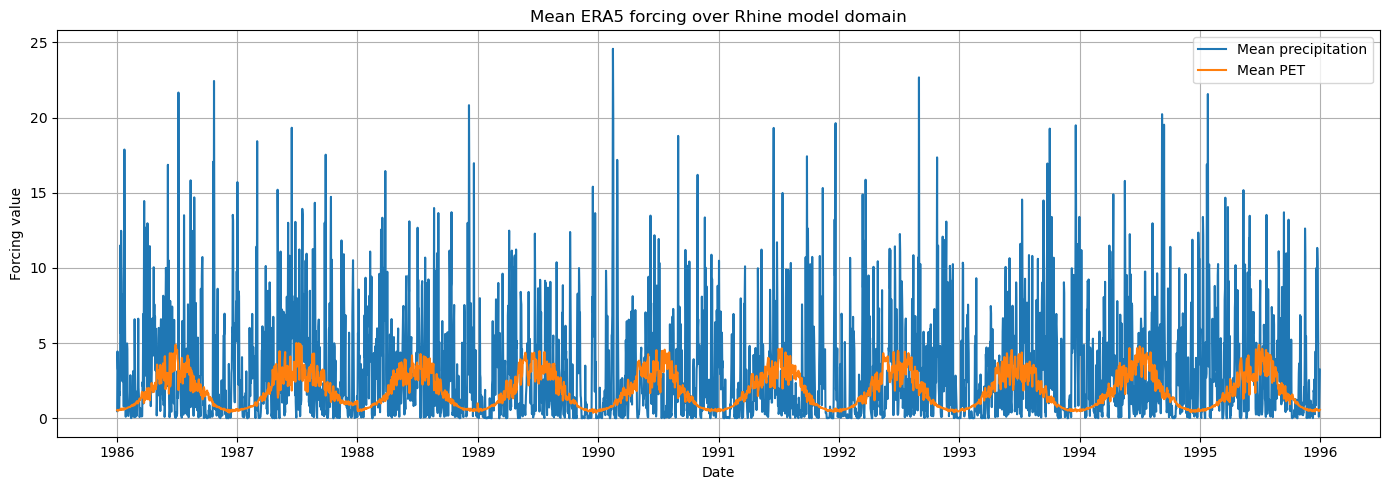

In [89]:
ds = xr.open_dataset(forcing_file)

p_mean = ds["pr"].mean(dim=["lat", "lon"]).to_dataframe().reset_index()
pet_mean = ds["pet"].mean(dim=["lat", "lon"]).to_dataframe().reset_index()

ds.close()

p_mean["time"] = pd.to_datetime(p_mean["time"])
pet_mean["time"] = pd.to_datetime(pet_mean["time"])

plt.figure(figsize=(14, 5))
plt.plot(p_mean["time"], p_mean["pr"], label="Mean precipitation")
plt.plot(pet_mean["time"], pet_mean["pet"], label="Mean PET")

plt.xlabel("Date")
plt.ylabel("Forcing value")
plt.title("Mean ERA5 forcing over Rhine model domain")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [90]:
ds = xr.open_dataset(forcing_file)

print("pr attributes:")
print(ds["pr"].attrs)

print("\npet attributes:")
print(ds["pet"].attrs)

ds.close()


pr attributes:
{'standard_name': 'precipitation_flux', 'long_name': 'Precipitation', 'units': 'mm day-1', 'cell_methods': 'day_of_year: year: mean'}

pet attributes:
{'standard_name': 'water_potential_evaporation_flux', 'long_name': 'Potential Evapotranspiration', 'units': 'mm day-1'}


In [91]:
factors = {
    "EoverR.tbl": 0.5,
    "RootingDepth.tbl": 0.75,
    "N_River.tbl": 3.0
}

model_calibrated_2 = run_calibration_model(
    run_name="calibrated_ET_Root_NRiver3_1987_1991",
    factors=factors
)

Runmap aangemaakt:
/home/niels/BEP-Niels/temp_runs/run_calibrated_ET_Root_NRiver3_1987_1991

Parameters vóór aanpassing:

Parameter: EoverR.tbl
Aantal bestanden gevonden: 1
intbl/EoverR.tbl
min: 0.11 max: 0.15 mean: 0.12

Parameter: RootingDepth.tbl
Aantal bestanden gevonden: 1
intbl/RootingDepth.tbl
min: 2.0 max: 525.0 mean: 107.88

Parameter: N_River.tbl
Aantal bestanden gevonden: 1
intbl/N_River.tbl
min: 0.027 max: 0.18 mean: 0.09
Aanpassen: intbl/EoverR.tbl factor: 0.5
Aanpassen: intbl/RootingDepth.tbl factor: 0.75
Aanpassen: intbl/N_River.tbl factor: 3.0

Parameters na aanpassing:

Parameter: EoverR.tbl
Aantal bestanden gevonden: 1
intbl/EoverR.tbl
min: 0.055 max: 0.075 mean: 0.06

Parameter: RootingDepth.tbl
Aantal bestanden gevonden: 1
intbl/RootingDepth.tbl
min: 1.5 max: 393.75 mean: 80.91

Parameter: N_River.tbl
Aantal bestanden gevonden: 1
intbl/N_River.tbl
min: 0.081 max: 0.54 mean: 0.28
Stap: 365 Tijd: 1986-12-31 00:00:00 Q: 10179.7
Stap: 730 Tijd: 1987-12-31 00:00:00 Q: 33

In [92]:
model_calibrated_2 = model_calibrated_2.rename(
    columns={"Q_model_m3s": "Q_calibrated_2_m3s"}
)

comparison_calibrated_2 = pd.merge(
    comparison,
    model_calibrated_2[["date", "Q_calibrated_2_m3s"]],
    on="date",
    how="inner"
)

In [93]:
comparison_final = comparison_calibrated_2.merge(
    comparison_calibrated_1[["date", "Q_calibrated_1_m3s"]],
    on="date",
    how="inner"
)

model_columns = {
    "basisrun": "Q_basis_m3s",
    "calibrated_1": "Q_calibrated_1_m3s",
    "calibrated_2": "Q_calibrated_2_m3s"
}

score_all = make_score_table(
    comparison_final,
    model_columns
)

score_low = make_score_table(
    comparison_final[
        comparison_final["Q_grdc_m3s"] < 1600
    ],
    model_columns
)

score_all

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,basisrun,582.0,1876.4,-1.042,1826
1,calibrated_1,643.1,1703.2,-0.556,1826
2,calibrated_2,642.1,1649.2,-0.429,1826


In [94]:
score_low

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,basisrun,-147.0,740.8,-21.205,669
1,calibrated_1,37.4,750.6,-13.760,669
2,calibrated_2,181.1,789.9,-11.363,669


In [95]:
threshold_table = []

for run_name, q_col in model_columns.items():
    threshold_table.append({
        "run": run_name,
        "days_below_1600": (comparison_final[q_col] < 1600).sum(),
        "days_below_1020": (comparison_final[q_col] < 1020).sum()
    })

threshold_table = pd.DataFrame(threshold_table)

print("GRDC dagen < 1600:", (comparison_final["Q_grdc_m3s"] < 1600).sum())
print("GRDC dagen < 1020:", (comparison_final["Q_grdc_m3s"] < 1020).sum())

threshold_table

GRDC dagen < 1600: 669
GRDC dagen < 1020: 96


,run,days_below_1600,days_below_1020
0,basisrun,760,485
1,calibrated_1,701,379
2,calibrated_2,668,304


In [96]:
q_cols = {
    "GRDC": "Q_grdc_m3s",
    "basisrun": "Q_basis_m3s",
    "calibrated_1": "Q_calibrated_1_m3s",
    "calibrated_2": "Q_calibrated_2_m3s"
}

rows = []

for name, col in q_cols.items():
    rows.append({
        "run": name,
        "Q5": comparison_final[col].quantile(0.05),
        "Q10": comparison_final[col].quantile(0.10),
        "Q20": comparison_final[col].quantile(0.20),
        "median": comparison_final[col].quantile(0.50),
        "mean": comparison_final[col].mean()
    })

quantile_table = pd.DataFrame(rows)
quantile_table.round(1)

,run,Q5,Q10,Q20,median,mean
0,GRDC,1015.0,1131.0,1318.0,1836.5,2223.3
1,basisrun,365.4,496.5,832.5,1911.0,2805.3
2,calibrated_1,505.3,654.8,1002.1,2076.3,2866.4
3,calibrated_2,595.6,755.6,1092.3,2136.2,2865.4


In [97]:
factors = {
    "EoverR.tbl": 0.75,
    "RootingDepth.tbl": 0.90,
    "N_River.tbl": 4.0
}

model_calibrated_3 = run_calibration_model(
    run_name="calibrated_balanced_ET075_Root090_NRiver4_1987_1991",
    factors=factors
)

Runmap aangemaakt:
/home/niels/BEP-Niels/temp_runs/run_calibrated_balanced_ET075_Root090_NRiver4_1987_1991

Parameters vóór aanpassing:

Parameter: EoverR.tbl
Aantal bestanden gevonden: 1
intbl/EoverR.tbl
min: 0.11 max: 0.15 mean: 0.12

Parameter: RootingDepth.tbl
Aantal bestanden gevonden: 1
intbl/RootingDepth.tbl
min: 2.0 max: 525.0 mean: 107.88

Parameter: N_River.tbl
Aantal bestanden gevonden: 1
intbl/N_River.tbl
min: 0.027 max: 0.18 mean: 0.09
Aanpassen: intbl/EoverR.tbl factor: 0.75
Aanpassen: intbl/RootingDepth.tbl factor: 0.9
Aanpassen: intbl/N_River.tbl factor: 4.0

Parameters na aanpassing:

Parameter: EoverR.tbl
Aantal bestanden gevonden: 1
intbl/EoverR.tbl
min: 0.0825 max: 0.11249999999999999 mean: 0.09

Parameter: RootingDepth.tbl
Aantal bestanden gevonden: 1
intbl/RootingDepth.tbl
min: 1.8 max: 472.5 mean: 97.09

Parameter: N_River.tbl
Aantal bestanden gevonden: 1
intbl/N_River.tbl
min: 0.108 max: 0.72 mean: 0.37
Stap: 365 Tijd: 1986-12-31 00:00:00 Q: 7962.2
Stap: 730 Tij

In [98]:
model_calibrated_3 = model_calibrated_3.rename(
    columns={"Q_model_m3s": "Q_calibrated_3_m3s"}
)

comparison_calibrated_3 = pd.merge(
    comparison_final,
    model_calibrated_3[["date", "Q_calibrated_3_m3s"]],
    on="date",
    how="inner"
)

In [99]:
model_columns = {
    "basisrun": "Q_basis_m3s",
    "calibrated_1": "Q_calibrated_1_m3s",
    "calibrated_2": "Q_calibrated_2_m3s",
    "calibrated_3": "Q_calibrated_3_m3s"
}

score_all = make_score_table(
    comparison_calibrated_3,
    model_columns
)

score_low = make_score_table(
    comparison_calibrated_3[
        comparison_calibrated_3["Q_grdc_m3s"] < 1600
    ],
    model_columns
)

score_all

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,basisrun,582.0,1876.4,-1.042,1826
1,calibrated_1,643.1,1703.2,-0.556,1826
2,calibrated_2,642.1,1649.2,-0.429,1826
3,calibrated_3,608.3,1620.7,-0.391,1826


In [100]:
score_low

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,basisrun,-147.0,740.8,-21.205,669
1,calibrated_1,37.4,750.6,-13.760,669
2,calibrated_2,181.1,789.9,-11.363,669
3,calibrated_3,260.1,815.6,-10.283,669


In [101]:
q_cols = {
    "GRDC": "Q_grdc_m3s",
    "basisrun": "Q_basis_m3s",
    "calibrated_1": "Q_calibrated_1_m3s",
    "calibrated_2": "Q_calibrated_2_m3s",
    "calibrated_3": "Q_calibrated_3_m3s"
}

rows = []

for name, col in q_cols.items():
    rows.append({
        "run": name,
        "Q5": comparison_calibrated_3[col].quantile(0.05),
        "Q10": comparison_calibrated_3[col].quantile(0.10),
        "Q20": comparison_calibrated_3[col].quantile(0.20),
        "median": comparison_calibrated_3[col].quantile(0.50),
        "mean": comparison_calibrated_3[col].mean()
    })

quantile_table = pd.DataFrame(rows)
quantile_table.round(1)

,run,Q5,Q10,Q20,median,mean
0,GRDC,1015.0,1131.0,1318.0,1836.5,2223.3
1,basisrun,365.4,496.5,832.5,1911.0,2805.3
2,calibrated_1,505.3,654.8,1002.1,2076.3,2866.4
3,calibrated_2,595.6,755.6,1092.3,2136.2,2865.4
4,calibrated_3,649.4,811.6,1162.0,2167.7,2831.7


In [102]:
threshold_table = []

for run_name, q_col in model_columns.items():
    threshold_table.append({
        "run": run_name,
        "days_below_1600": (comparison_calibrated_3[q_col] < 1600).sum(),
        "days_below_1020": (comparison_calibrated_3[q_col] < 1020).sum()
    })

threshold_table = pd.DataFrame(threshold_table)

print("GRDC dagen < 1600:", (comparison_calibrated_3["Q_grdc_m3s"] < 1600).sum())
print("GRDC dagen < 1020:", (comparison_calibrated_3["Q_grdc_m3s"] < 1020).sum())

threshold_table

GRDC dagen < 1600: 669
GRDC dagen < 1020: 96


,run,days_below_1600,days_below_1020
0,basisrun,760,485
1,calibrated_1,701,379
2,calibrated_2,668,304
3,calibrated_3,660,286


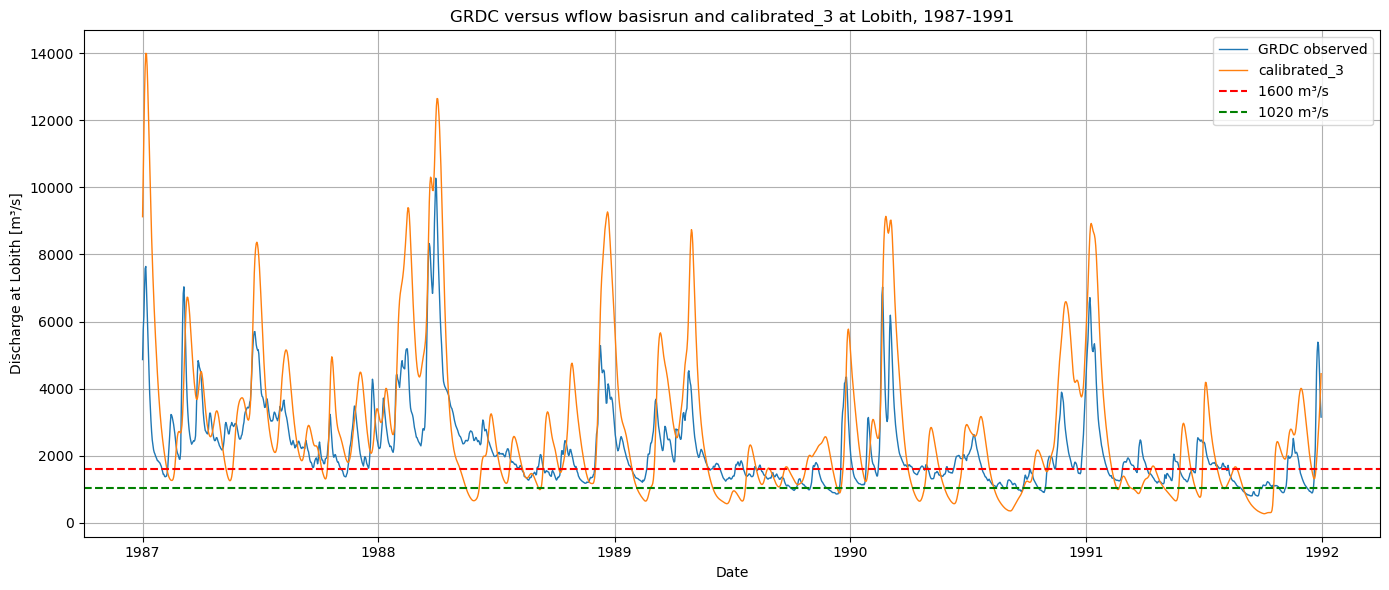

In [106]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison_calibrated_3["date"],
    comparison_calibrated_3["Q_grdc_m3s"],
    label="GRDC observed",
    linewidth=1.0
)

# plt.plot(
#     comparison_calibrated_3["date"],
#     comparison_calibrated_3["Q_basis_m3s"],
#     label="basisrun",
#     linewidth=0.8,
#     alpha=0.8
# )

plt.plot(
    comparison_calibrated_3["date"],
    comparison_calibrated_3["Q_calibrated_3_m3s"],
    label="calibrated_3",
    linewidth=1.0
)

plt.axhline(1600, linestyle="--", label="1600 m³/s", color='r')
plt.axhline(1020, linestyle="--", label="1020 m³/s", color='green')

plt.xlabel("Date")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title("GRDC versus wflow basisrun and calibrated_3 at Lobith, 1987-1991")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

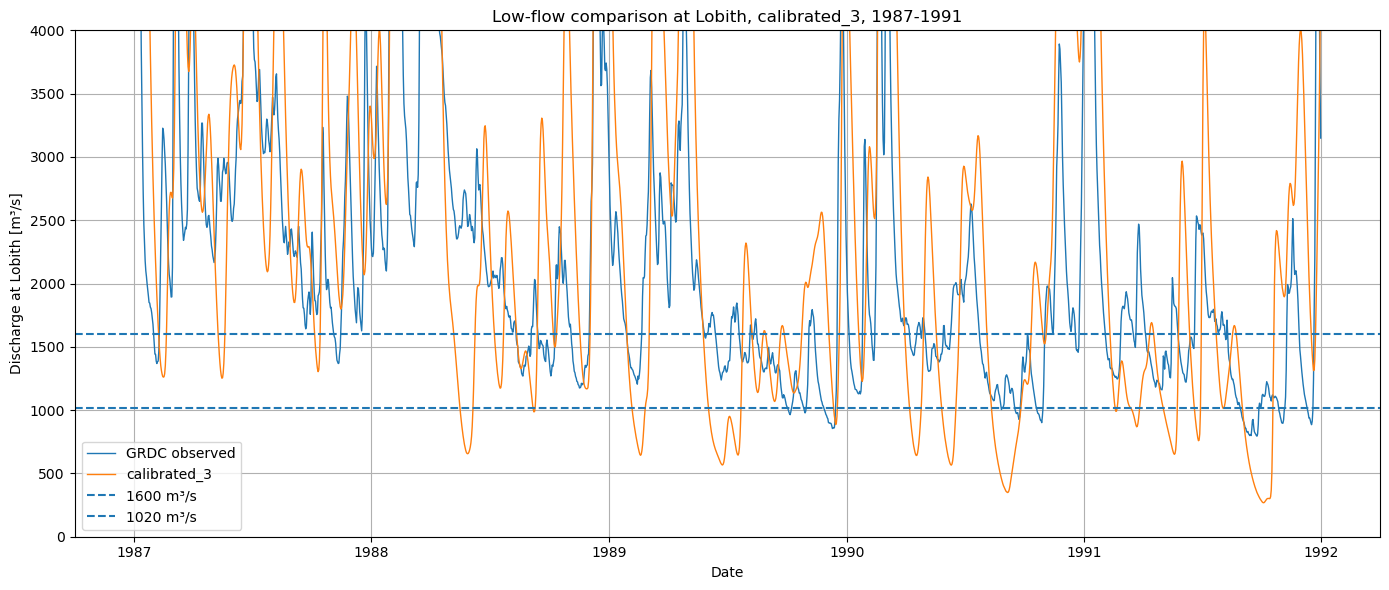

In [108]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison_calibrated_3["date"],
    comparison_calibrated_3["Q_grdc_m3s"],
    label="GRDC observed",
    linewidth=1.0
)

# plt.plot(
#     comparison_calibrated_3["date"],
#     comparison_calibrated_3["Q_basis_m3s"],
#     label="basisrun",
#     linewidth=0.8,
#     alpha=0.8
# )

plt.plot(
    comparison_calibrated_3["date"],
    comparison_calibrated_3["Q_calibrated_3_m3s"],
    label="calibrated_3",
    linewidth=1.0
)

plt.axhline(1600, linestyle="--", label="1600 m³/s")
plt.axhline(1020, linestyle="--", label="1020 m³/s")

plt.ylim(0, 4000)

plt.xlabel("Date")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title("Low-flow comparison at Lobith, calibrated_3, 1987-1991")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [109]:
factors = {
    "EoverR.tbl": 0.85,
    "RootingDepth.tbl": 0.95,
    "N_River.tbl": 6.0
}

model_calibrated_4 = run_calibration_model(
    run_name="calibrated_balanced_ET085_Root095_NRiver6_1987_1991",
    factors=factors
)

Runmap aangemaakt:
/home/niels/BEP-Niels/temp_runs/run_calibrated_balanced_ET085_Root095_NRiver6_1987_1991

Parameters vóór aanpassing:

Parameter: EoverR.tbl
Aantal bestanden gevonden: 1
intbl/EoverR.tbl
min: 0.11 max: 0.15 mean: 0.12

Parameter: RootingDepth.tbl
Aantal bestanden gevonden: 1
intbl/RootingDepth.tbl
min: 2.0 max: 525.0 mean: 107.88

Parameter: N_River.tbl
Aantal bestanden gevonden: 1
intbl/N_River.tbl
min: 0.027 max: 0.18 mean: 0.09
Aanpassen: intbl/EoverR.tbl factor: 0.85
Aanpassen: intbl/RootingDepth.tbl factor: 0.95
Aanpassen: intbl/N_River.tbl factor: 6.0

Parameters na aanpassing:

Parameter: EoverR.tbl
Aantal bestanden gevonden: 1
intbl/EoverR.tbl
min: 0.0935 max: 0.1275 mean: 0.1

Parameter: RootingDepth.tbl
Aantal bestanden gevonden: 1
intbl/RootingDepth.tbl
min: 1.9 max: 498.75 mean: 102.49

Parameter: N_River.tbl
Aantal bestanden gevonden: 1
intbl/N_River.tbl
min: 0.162 max: 1.08 mean: 0.56
Stap: 365 Tijd: 1986-12-31 00:00:00 Q: 5597.9
Stap: 730 Tijd: 1987-12-

In [110]:
model_calibrated_4 = model_calibrated_4.rename(
    columns={"Q_model_m3s": "Q_calibrated_4_m3s"}
)

comparison_calibrated_4 = pd.merge(
    comparison_calibrated_3,
    model_calibrated_4[["date", "Q_calibrated_4_m3s"]],
    on="date",
    how="inner"
)

In [111]:
model_columns = {
    "basisrun": "Q_basis_m3s",
    "calibrated_2": "Q_calibrated_2_m3s",
    "calibrated_3": "Q_calibrated_3_m3s",
    "calibrated_4": "Q_calibrated_4_m3s"
}

score_all = make_score_table(
    comparison_calibrated_4,
    model_columns
)

score_low = make_score_table(
    comparison_calibrated_4[
        comparison_calibrated_4["Q_grdc_m3s"] < 1600
    ],
    model_columns
)

score_all

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,basisrun,582.0,1876.4,-1.042,1826
1,calibrated_2,642.1,1649.2,-0.429,1826
2,calibrated_3,608.3,1620.7,-0.391,1826
3,calibrated_4,602.0,1626.9,-0.349,1826


In [112]:
score_low

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,basisrun,-147.0,740.8,-21.205,669
1,calibrated_2,181.1,789.9,-11.363,669
2,calibrated_3,260.1,815.6,-10.283,669
3,calibrated_4,355.3,881.6,-9.548,669


In [114]:
threshold_table = []

for run_name, q_col in model_columns.items():
    threshold_table.append({
        "run": run_name,
        "days_below_1600": (comparison_calibrated_4[q_col] < 1600).sum(),
        "days_below_1020": (comparison_calibrated_4[q_col] < 1020).sum()
    })

threshold_table = pd.DataFrame(threshold_table)

print("GRDC dagen < 1600:", (comparison_calibrated_4["Q_grdc_m3s"] < 1600).sum())
print("GRDC dagen < 1020:", (comparison_calibrated_4["Q_grdc_m3s"] < 1020).sum())

threshold_table

GRDC dagen < 1600: 669
GRDC dagen < 1020: 96


,run,days_below_1600,days_below_1020
0,basisrun,760,485
1,calibrated_2,668,304
2,calibrated_3,660,286
3,calibrated_4,612,245


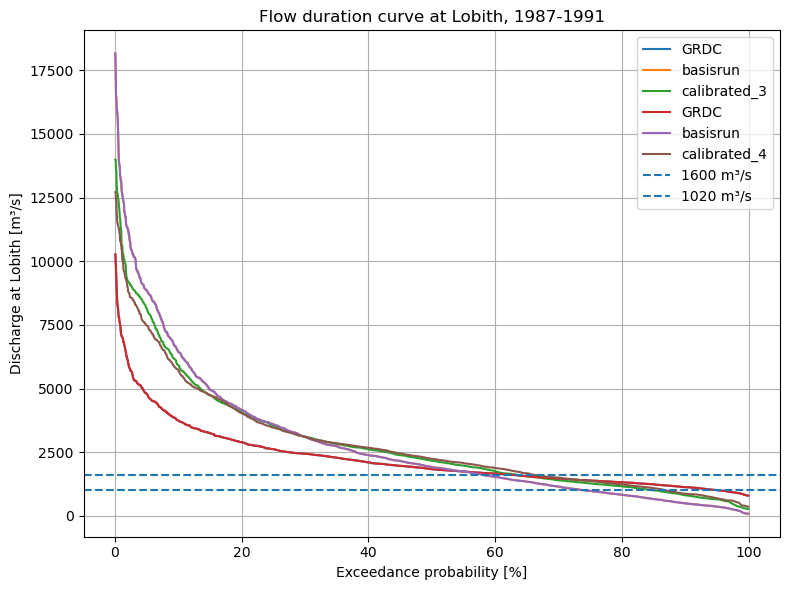

In [118]:
plt.figure(figsize=(8, 6))

for label, col in {
    "GRDC": "Q_grdc_m3s",
    "basisrun": "Q_basis_m3s",
    "calibrated_3": "Q_calibrated_3_m3s"
}.items():
    q_sorted = np.sort(comparison_calibrated_3[col].values)[::-1]
    exceedance = np.arange(1, len(q_sorted) + 1) / (len(q_sorted) + 1) * 100
    
    plt.plot(exceedance, q_sorted, label=label)

for label, col in {
    "GRDC": "Q_grdc_m3s",
    "basisrun": "Q_basis_m3s",
    "calibrated_4": "Q_calibrated_4_m3s"
}.items():
    q_sorted = np.sort(comparison_calibrated_4[col].values)[::-1]
    exceedance = np.arange(1, len(q_sorted) + 1) / (len(q_sorted) + 1) * 100
    
    plt.plot(exceedance, q_sorted, label=label)

plt.axhline(1600, linestyle="--", label="1600 m³/s")
plt.axhline(1020, linestyle="--", label="1020 m³/s")

plt.xlabel("Exceedance probability [%]")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title("Flow duration curve at Lobith, 1987-1991")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [119]:
factors = {
    "N_River.tbl": 6.0
}

model_calibrated_5 = run_calibration_model(
    run_name="calibrated_NRiver6_only_1987_1991",
    factors=factors
)

Runmap aangemaakt:
/home/niels/BEP-Niels/temp_runs/run_calibrated_NRiver6_only_1987_1991

Parameters vóór aanpassing:

Parameter: N_River.tbl
Aantal bestanden gevonden: 1
intbl/N_River.tbl
min: 0.027 max: 0.18 mean: 0.09
Aanpassen: intbl/N_River.tbl factor: 6.0

Parameters na aanpassing:

Parameter: N_River.tbl
Aantal bestanden gevonden: 1
intbl/N_River.tbl
min: 0.162 max: 1.08 mean: 0.56
Stap: 365 Tijd: 1986-12-31 00:00:00 Q: 5594.2
Stap: 730 Tijd: 1987-12-31 00:00:00 Q: 3131.7
Stap: 1095 Tijd: 1988-12-30 00:00:00 Q: 7867.0
Stap: 1460 Tijd: 1989-12-30 00:00:00 Q: 4656.4
Stap: 1825 Tijd: 1990-12-30 00:00:00 Q: 4032.8
Stap: 2190 Tijd: 1991-12-30 00:00:00 Q: 2852.7

Run klaar: calibrated_NRiver6_only_1987_1991
Aantal dagen: 1826
Opgeslagen als: /home/niels/BEP-Niels/results/calibrated_NRiver6_only_1987_1991_lobith_daily.csv


In [120]:
model_calibrated_5 = model_calibrated_5.rename(
    columns={"Q_model_m3s": "Q_calibrated_5_m3s"}
)

comparison_calibrated_5 = pd.merge(
    comparison_calibrated_4,
    model_calibrated_5[["date", "Q_calibrated_5_m3s"]],
    on="date",
    how="inner"
)

In [121]:
model_columns = {
    "basisrun": "Q_basis_m3s",
    "calibrated_3": "Q_calibrated_3_m3s",
    "calibrated_4": "Q_calibrated_4_m3s",
    "calibrated_5": "Q_calibrated_5_m3s"
}

score_all = make_score_table(
    comparison_calibrated_5,
    model_columns
)

score_low = make_score_table(
    comparison_calibrated_5[
        comparison_calibrated_5["Q_grdc_m3s"] < 1600
    ],
    model_columns
)

score_all

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,basisrun,582.0,1876.4,-1.042,1826
1,calibrated_3,608.3,1620.7,-0.391,1826
2,calibrated_4,602.0,1626.9,-0.349,1826
3,calibrated_5,588.8,1621.0,-0.353,1826


In [122]:
score_low

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,basisrun,-147.0,740.8,-21.205,669
1,calibrated_3,260.1,815.6,-10.283,669
2,calibrated_4,355.3,881.6,-9.548,669
3,calibrated_5,343.2,875.0,-9.572,669


In [123]:
threshold_table = []

for run_name, q_col in model_columns.items():
    threshold_table.append({
        "run": run_name,
        "days_below_1600": (comparison_calibrated_5[q_col] < 1600).sum(),
        "days_below_1020": (comparison_calibrated_5[q_col] < 1020).sum()
    })

threshold_table = pd.DataFrame(threshold_table)

print("GRDC dagen < 1600:", (comparison_calibrated_5["Q_grdc_m3s"] < 1600).sum())
print("GRDC dagen < 1020:", (comparison_calibrated_5["Q_grdc_m3s"] < 1020).sum())

threshold_table

GRDC dagen < 1600: 669
GRDC dagen < 1020: 96


,run,days_below_1600,days_below_1020
0,basisrun,760,485
1,calibrated_3,660,286
2,calibrated_4,612,245
3,calibrated_5,619,248


In [124]:
def quantile_mapping(obs, sim, sim_to_correct, n_quantiles=101):
    obs = np.array(obs)
    sim = np.array(sim)
    sim_to_correct = np.array(sim_to_correct)

    qs = np.linspace(0, 1, n_quantiles)

    sim_q = np.quantile(sim, qs)
    obs_q = np.quantile(obs, qs)

    # dubbele waarden verwijderen, anders kan np.interp problemen geven
    sim_q_unique, unique_index = np.unique(sim_q, return_index=True)
    obs_q_unique = obs_q[unique_index]

    corrected = np.interp(
        sim_to_correct,
        sim_q_unique,
        obs_q_unique,
        left=obs_q_unique[0],
        right=obs_q_unique[-1]
    )

    return corrected

In [125]:
comparison_bc = comparison_calibrated_3.copy()

comparison_bc["Q_calibrated_3_bc_m3s"] = quantile_mapping(
    obs=comparison_bc["Q_grdc_m3s"],
    sim=comparison_bc["Q_calibrated_3_m3s"],
    sim_to_correct=comparison_bc["Q_calibrated_3_m3s"],
    n_quantiles=101
)

comparison_bc.head()

,date,Q_grdc_m3s,Q_basis_m3s,Q_calibrated_2_m3s,Q_calibrated_1_m3s,Q_calibrated_3_m3s,Q_calibrated_3_bc_m3s
0,1987-01-01,4865.0,13869.678711,11196.812500,12154.388672,9125.787109,5859.027112
1,1987-01-02,5756.0,15741.568359,12298.969727,13527.861328,10393.553711,6880.835734
2,1987-01-03,6160.0,16061.675781,13359.584961,14634.554688,11656.896484,8028.542373
3,1987-01-04,6973.0,15124.300781,14143.637695,15006.872070,12782.655273,9108.684010
4,1987-01-05,7579.0,13978.630859,14459.563477,14692.697266,13590.301758,9883.603650


In [126]:
model_columns = {
    "basisrun": "Q_basis_m3s",
    "calibrated_3": "Q_calibrated_3_m3s",
    "calibrated_3_bc": "Q_calibrated_3_bc_m3s"
}

score_all = make_score_table(
    comparison_bc,
    model_columns
)

score_low = make_score_table(
    comparison_bc[
        comparison_bc["Q_grdc_m3s"] < 1600
    ],
    model_columns
)

score_all

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,basisrun,582.0,1876.4,-1.042,1826
1,calibrated_3,608.3,1620.7,-0.391,1826
2,calibrated_3_bc,4.8,827.0,0.449,1826


In [127]:
score_low

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,basisrun,-147.0,740.8,-21.205,669
1,calibrated_3,260.1,815.6,-10.283,669
2,calibrated_3_bc,252.5,503.4,-2.868,669


In [128]:
threshold_table = []

for run_name, q_col in model_columns.items():
    threshold_table.append({
        "run": run_name,
        "days_below_1600": (comparison_bc[q_col] < 1600).sum(),
        "days_below_1020": (comparison_bc[q_col] < 1020).sum()
    })

threshold_table = pd.DataFrame(threshold_table)

print("GRDC dagen < 1600:", (comparison_bc["Q_grdc_m3s"] < 1600).sum())
print("GRDC dagen < 1020:", (comparison_bc["Q_grdc_m3s"] < 1020).sum())

threshold_table

GRDC dagen < 1600: 669
GRDC dagen < 1020: 96


,run,days_below_1600,days_below_1020
0,basisrun,760,485
1,calibrated_3,660,286
2,calibrated_3_bc,671,96


In [129]:
q_cols = {
    "GRDC": "Q_grdc_m3s",
    "basisrun": "Q_basis_m3s",
    "calibrated_3": "Q_calibrated_3_m3s",
    "calibrated_3_bc": "Q_calibrated_3_bc_m3s"
}

rows = []

for name, col in q_cols.items():
    rows.append({
        "run": name,
        "Q5": comparison_bc[col].quantile(0.05),
        "Q10": comparison_bc[col].quantile(0.10),
        "Q20": comparison_bc[col].quantile(0.20),
        "median": comparison_bc[col].quantile(0.50),
        "mean": comparison_bc[col].mean()
    })

quantile_table = pd.DataFrame(rows)
quantile_table.round(1)

,run,Q5,Q10,Q20,median,mean
0,GRDC,1015.0,1131.0,1318.0,1836.5,2223.3
1,basisrun,365.4,496.5,832.5,1911.0,2805.3
2,calibrated_3,649.4,811.6,1162.0,2167.7,2831.7
3,calibrated_3_bc,1015.0,1131.0,1318.0,1836.5,2228.1


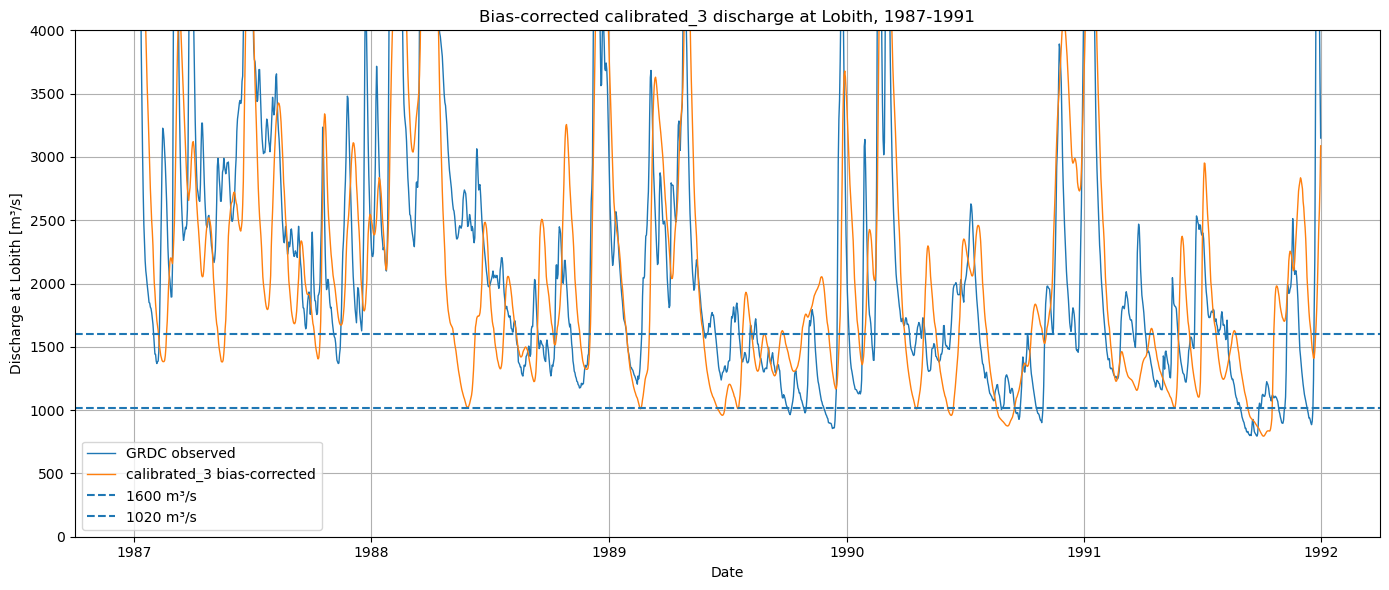

In [131]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison_bc["date"],
    comparison_bc["Q_grdc_m3s"],
    label="GRDC observed",
    linewidth=1.0
)

# plt.plot(
#     comparison_bc["date"],
#     comparison_bc["Q_calibrated_3_m3s"],
#     label="calibrated_3",
#     linewidth=0.8,
#     alpha=0.8
# )

plt.plot(
    comparison_bc["date"],
    comparison_bc["Q_calibrated_3_bc_m3s"],
    label="calibrated_3 bias-corrected",
    linewidth=1.0
)

plt.axhline(1600, linestyle="--", label="1600 m³/s")
plt.axhline(1020, linestyle="--", label="1020 m³/s")

plt.ylim(0, 4000)

plt.xlabel("Date")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title("Bias-corrected calibrated_3 discharge at Lobith, 1987-1991")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [132]:
output_file = results_dir / "calibrated_3_bias_corrected_1987_1991_lobith.csv"

comparison_bc[[
    "date",
    "Q_grdc_m3s",
    "Q_basis_m3s",
    "Q_calibrated_3_m3s",
    "Q_calibrated_3_bc_m3s"
]].to_csv(output_file, index=False)

print("Opgeslagen als:")
print(output_file)

Opgeslagen als:
/home/niels/BEP-Niels/results/calibrated_3_bias_corrected_1987_1991_lobith.csv


In [135]:
ds = xr.open_dataset(forcing_file)

print("Start forcing:", ds["time"].values[0])
print("Einde forcing:", ds["time"].values[-1])

ds.close()

Start forcing: 1986-01-01T12:00:00.000000000
Einde forcing: 1995-12-31T12:00:00.000000000


In [136]:
def fit_quantile_mapping(obs_train, sim_train, n_quantiles=101):
    obs_train = np.array(obs_train)
    sim_train = np.array(sim_train)

    qs = np.linspace(0, 1, n_quantiles)

    sim_q = np.quantile(sim_train, qs)
    obs_q = np.quantile(obs_train, qs)

    # dubbele simulatiewaarden verwijderen
    sim_q_unique, unique_index = np.unique(sim_q, return_index=True)
    obs_q_unique = obs_q[unique_index]

    return sim_q_unique, obs_q_unique


def apply_quantile_mapping(sim_values, sim_q, obs_q):
    sim_values = np.array(sim_values)

    corrected = np.interp(
        sim_values,
        sim_q,
        obs_q,
        left=obs_q[0],
        right=obs_q[-1]
    )

    return corrected

In [137]:
sim_q_cal, obs_q_cal = fit_quantile_mapping(
    obs_train=comparison_calibrated_3["Q_grdc_m3s"],
    sim_train=comparison_calibrated_3["Q_calibrated_3_m3s"],
    n_quantiles=101
)

In [138]:
model_start = "1991-01-01T00:00:00Z"
model_end = "1996-01-01T00:00:00Z"

calibration_start = "1992-01-01"
calibration_end = "1995-12-31"

In [139]:
forcing = WflowForcing(
    start_time=model_start,
    end_time=model_end,
    directory=str(forcing_dir),
    shape=str(shape_file),
    netcdfinput="wflow_ERA5_Rhine_1986_1995.nc",
    Precipitation="/pr",
    EvapoTranspiration="/pet",
    Temperature="/tas",
    Inflow=None,
)

print(forcing)

start_time='1991-01-01T00:00:00Z' end_time='1996-01-01T00:00:00Z' directory=PosixPath('/home/niels/BEP-Niels/temp_runs/forcing_basisrun_1987_1995/work/diagnostic/script') shape=PosixPath('/home/niels/BEP-Niels/Rhine/Rhine.shp') filenames={} netcdfinput='wflow_ERA5_Rhine_1986_1995.nc' Precipitation='/pr' EvapoTranspiration='/pet' Temperature='/tas' Inflow=None


In [140]:
grdc_validation = df[
    (df["date"] >= calibration_start) &
    (df["date"] <= calibration_end)
].copy()

grdc_validation = grdc_validation[["date", "Q_m3s"]]
grdc_validation = grdc_validation.rename(columns={"Q_m3s": "Q_grdc_m3s"})

print("Aantal GRDC dagen:", len(grdc_validation))
print("Start:", grdc_validation["date"].min())
print("Einde:", grdc_validation["date"].max())

grdc_validation.head()

Aantal GRDC dagen: 1461
Start: 1992-01-01 00:00:00
Einde: 1995-12-31 00:00:00


,date,Q_grdc_m3s
33237,1992-01-01,2830.0
33238,1992-01-02,2592.0
33239,1992-01-03,2385.0
33240,1992-01-04,2182.0
33241,1992-01-05,2051.0


In [141]:
factors = {
    "EoverR.tbl": 0.75,
    "RootingDepth.tbl": 0.90,
    "N_River.tbl": 4.0
}

model_val_cal3 = run_calibration_model(
    run_name="validation_calibrated_3_1992_1995",
    factors=factors
)

Runmap aangemaakt:
/home/niels/BEP-Niels/temp_runs/run_validation_calibrated_3_1992_1995

Parameters vóór aanpassing:

Parameter: EoverR.tbl
Aantal bestanden gevonden: 1
intbl/EoverR.tbl
min: 0.11 max: 0.15 mean: 0.12

Parameter: RootingDepth.tbl
Aantal bestanden gevonden: 1
intbl/RootingDepth.tbl
min: 2.0 max: 525.0 mean: 107.88

Parameter: N_River.tbl
Aantal bestanden gevonden: 1
intbl/N_River.tbl
min: 0.027 max: 0.18 mean: 0.09
Aanpassen: intbl/EoverR.tbl factor: 0.75
Aanpassen: intbl/RootingDepth.tbl factor: 0.9
Aanpassen: intbl/N_River.tbl factor: 4.0

Parameters na aanpassing:

Parameter: EoverR.tbl
Aantal bestanden gevonden: 1
intbl/EoverR.tbl
min: 0.0825 max: 0.11249999999999999 mean: 0.09

Parameter: RootingDepth.tbl
Aantal bestanden gevonden: 1
intbl/RootingDepth.tbl
min: 1.8 max: 472.5 mean: 97.09

Parameter: N_River.tbl
Aantal bestanden gevonden: 1
intbl/N_River.tbl
min: 0.108 max: 0.72 mean: 0.37
Stap: 365 Tijd: 1991-12-31 00:00:00 Q: 4069.0
Stap: 730 Tijd: 1992-12-30 00:0

In [142]:
model_val_cal3 = model_val_cal3.rename(
    columns={"Q_model_m3s": "Q_calibrated_3_raw_m3s"}
)

In [143]:
comparison_validation = pd.merge(
    grdc_validation,
    model_val_cal3[["date", "Q_calibrated_3_raw_m3s"]],
    on="date",
    how="inner"
)

comparison_validation["Q_calibrated_3_bc_m3s"] = apply_quantile_mapping(
    sim_values=comparison_validation["Q_calibrated_3_raw_m3s"],
    sim_q=sim_q_cal,
    obs_q=obs_q_cal
)

comparison_validation.head()

,date,Q_grdc_m3s,Q_calibrated_3_raw_m3s,Q_calibrated_3_bc_m3s
0,1992-01-01,2830.0,4687.523926,3220.229456
1,1992-01-02,2592.0,5362.611816,3502.031651
2,1992-01-03,2385.0,5960.216309,3762.855604
3,1992-01-04,2182.0,6366.939941,3958.154849
4,1992-01-05,2051.0,6547.212402,4057.753077


In [144]:
model_columns = {
    "calibrated_3_raw": "Q_calibrated_3_raw_m3s",
    "calibrated_3_bc": "Q_calibrated_3_bc_m3s"
}

score_validation_all = make_score_table(
    comparison_validation,
    model_columns
)

score_validation_low = make_score_table(
    comparison_validation[
        comparison_validation["Q_grdc_m3s"] < 1600
    ],
    model_columns
)

score_validation_all

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,calibrated_3_raw,891.5,1816.7,-0.4,1461
1,calibrated_3_bc,108.0,782.5,0.5,1461


In [145]:
score_validation_low

,run,bias_m3s,rmse_m3s,log_nse,n_days
0,calibrated_3_raw,263.4,806.5,-12.571,481
1,calibrated_3_bc,225.4,484.1,-4.127,481


In [146]:
threshold_table = []

for run_name, q_col in model_columns.items():
    threshold_table.append({
        "run": run_name,
        "days_below_1600": (comparison_validation[q_col] < 1600).sum(),
        "days_below_1020": (comparison_validation[q_col] < 1020).sum()
    })

threshold_table = pd.DataFrame(threshold_table)

print("GRDC dagen < 1600:", (comparison_validation["Q_grdc_m3s"] < 1600).sum())
print("GRDC dagen < 1020:", (comparison_validation["Q_grdc_m3s"] < 1020).sum())

threshold_table

GRDC dagen < 1600: 481
GRDC dagen < 1020: 29


,run,days_below_1600,days_below_1020
0,calibrated_3_raw,426,217
1,calibrated_3_bc,431,34


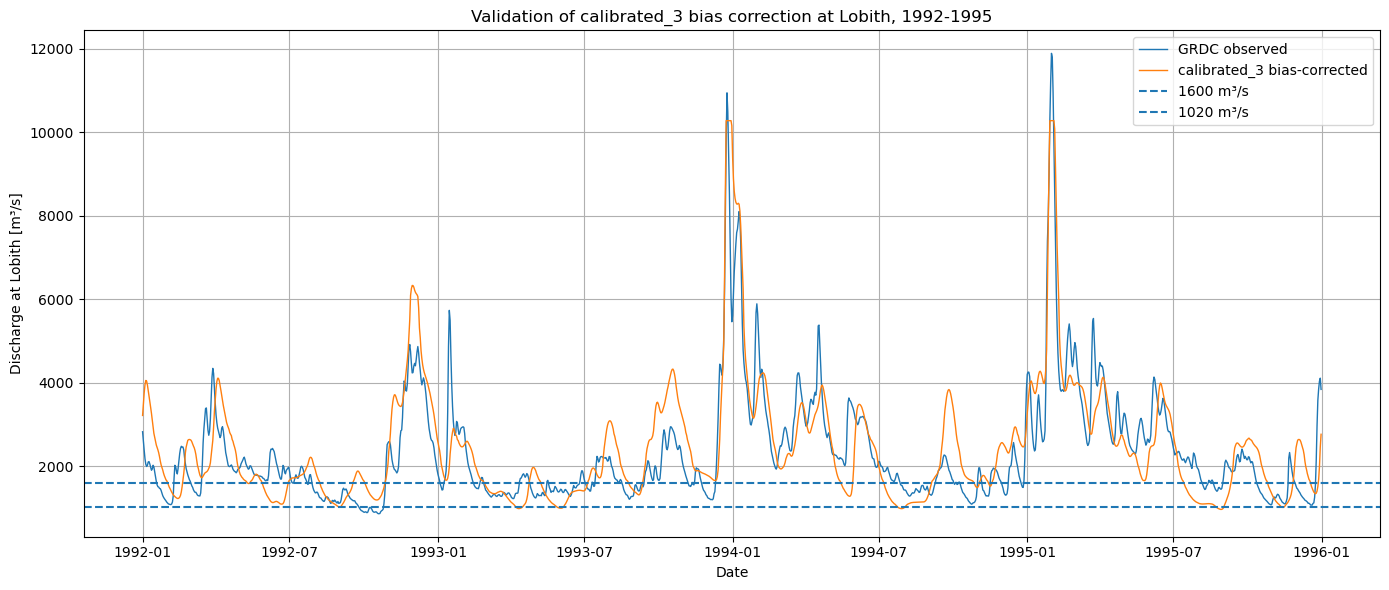

In [148]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison_validation["date"],
    comparison_validation["Q_grdc_m3s"],
    label="GRDC observed",
    linewidth=1.0
)

# plt.plot(
#     comparison_validation["date"],
#     comparison_validation["Q_calibrated_3_raw_m3s"],
#     label="calibrated_3 raw",
#     linewidth=0.8,
#     alpha=0.8
# )

plt.plot(
    comparison_validation["date"],
    comparison_validation["Q_calibrated_3_bc_m3s"],
    label="calibrated_3 bias-corrected",
    linewidth=1.0
)

plt.axhline(1600, linestyle="--", label="1600 m³/s")
plt.axhline(1020, linestyle="--", label="1020 m³/s")



plt.xlabel("Date")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title("Validation of calibrated_3 bias correction at Lobith, 1992-1995")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [149]:
from pathlib import Path
import os

temp_dir = Path("/home/niels/BEP-Niels/temp_runs")

def folder_size_gb(path):
    total = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for filename in filenames:
            file = Path(dirpath) / filename
            if file.exists():
                total += file.stat().st_size
    return total / 1e9

for item in sorted(temp_dir.iterdir()):
    if item.is_dir():
        print(item.name, round(folder_size_gb(item), 2), "GB")
    else:
        print(item.name, round(item.stat().st_size / 1e9, 3), "GB")

.ipynb_checkpoints 0.0 GB
forcing_basisrun_1980_1990 0.0 GB
forcing_basisrun_1987_1990 0.94 GB
forcing_basisrun_1987_1995 1.57 GB
forcing_wflow_lobith_1991_1992 0.47 GB
model_output_lobith_2005_2010_daily.xlsx 0.0 GB
run_basisrun_1987_1990 0.92 GB
run_basisrun_1987_1995 1.54 GB
run_calibrated_ET_Root_NRiver3_1987_1991 1.49 GB
run_calibrated_ET_Root_NRiver_1987_1991 1.49 GB
run_calibrated_NRiver6_only_1987_1991 1.49 GB
run_calibrated_balanced_ET075_Root090_NRiver4_1987_1991 1.49 GB
run_calibrated_balanced_ET085_Root095_NRiver6_1987_1991 1.49 GB
run_inspect_parameters 1.4 GB
run_lowflow_FirstZoneCapacity_x15_1987_1991 1.48 GB
run_lowflow_storage_leakage_1 1.54 GB
run_test_EoverR_x05_RootDepth_x075_1987_1991 1.49 GB
run_test_FirstZoneKsatVer_x05_1987_1991 1.48 GB
run_test_InfiltCapSoil_x15_1987_1991 1.48 GB
run_test_M_x15_1987_1991 1.48 GB
run_test_fzc15_1987_1991 1.48 GB
run_test_parameter_change 1.4 GB
run_validation_calibrated_3_1992_1995 1.47 GB
run_wflow_lobith_1991_1992 0.46 GB


In [150]:
# Mappen die veilig weg kunnen

folders_to_delete = [
    "forcing_basisrun_1980_1990",
    "forcing_basisrun_1987_1990",
    "forcing_wflow_lobith_1991_1992",
    
    "run_basisrun_1987_1990",
    "run_wflow_lobith_1991_1992",
    
    "run_inspect_parameters",
    "run_test_parameter_change",
    
    "run_lowflow_FirstZoneCapacity_x15_1987_1991",
    "run_lowflow_storage_leakage_1",
    
    "run_test_FirstZoneKsatVer_x05_1987_1991",
    "run_test_fzc15_1987_1991",
    "run_test_InfiltCapSoil_x15_1987_1991",
    "run_test_M_x15_1987_1991",
]

In [152]:
# Eerst controleren wat verwijderd zou worden

DRY_RUN = False

total_size = 0

for folder_name in folders_to_delete:
    folder = temp_dir / folder_name
    
    if folder.exists():
        size = folder_size_gb(folder)
        total_size += size
        
        if DRY_RUN:
            print("Zou verwijderen:", folder_name, "-", round(size, 2), "GB")
        else:
            print("Verwijderen:", folder_name, "-", round(size, 2), "GB")
            shutil.rmtree(folder)
    else:
        print("Niet gevonden:", folder_name)

print("\nTotale ruimte die vrijkomt:", round(total_size, 2), "GB")

Verwijderen: forcing_basisrun_1980_1990 - 0.0 GB
Verwijderen: forcing_basisrun_1987_1990 - 0.94 GB
Verwijderen: forcing_wflow_lobith_1991_1992 - 0.47 GB
Verwijderen: run_basisrun_1987_1990 - 0.92 GB
Verwijderen: run_wflow_lobith_1991_1992 - 0.46 GB
Verwijderen: run_inspect_parameters - 1.4 GB
Verwijderen: run_test_parameter_change - 1.4 GB
Verwijderen: run_lowflow_FirstZoneCapacity_x15_1987_1991 - 1.48 GB
Verwijderen: run_lowflow_storage_leakage_1 - 1.54 GB
Verwijderen: run_test_FirstZoneKsatVer_x05_1987_1991 - 1.48 GB
Verwijderen: run_test_fzc15_1987_1991 - 1.48 GB
Verwijderen: run_test_InfiltCapSoil_x15_1987_1991 - 1.48 GB
Verwijderen: run_test_M_x15_1987_1991 - 1.48 GB

Totale ruimte die vrijkomt: 14.56 GB
